# Campus Heat & Inertia Data Analysis — 13.03.2026

**Author**: Mihkel Uutar  
**Supervisor**: Prof. Juri Belikov, TalTech Department of Software Science  

This notebook explores **TalTech campus heat demand, ventilation, and building metadata** to prepare features and intuition for the thesis *"Inertia-Aware, Explainable Heat-Demand Forecasting for Estonian Apartment Buildings"*.

Where the main pipeline notebook focuses on **cleaning and exporting model-ready data**, this notebook focuses on **understanding structure and physics**:

- Which buildings have detailed **ventilation and subsystem meters**.
- How **district heating \\(\\Delta T\\)** behaves across buildings and seasons.
- What **EHR metadata** (energy marks, areas, envelope hints) exists and how complete it is.
- How these ingredients relate to **thermal inertia** and load-shifting potential.

All code here is read-only with respect to the core pipeline: it **does not modify** cleaning logic, only reads its outputs and the same raw campus/EHR sources.


## Cell 0 — Setup: imports, paths, and analysis scope

This cell mirrors the main data pipeline setup but keeps the focus on **exploratory analysis** rather than cleaning.

- Defines project paths and building list once, so every later section reuses the same constants.
- Configures plotting style for quick, readable comparison plots.
- Keeps all analysis-specific constants close together so the notebook is easy to tune during thesis work.

In [49]:
# Cell 0 — Imports, paths, and analysis configuration

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting defaults (aligned with main pipeline)
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 110

# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------
PROJECT_ROOT          = Path.cwd()
DATA_DIR              = PROJECT_ROOT / "data"
CAMPUS_DATA_DIR       = DATA_DIR / "campus-data"
OVERVIEW_FILE         = CAMPUS_DATA_DIR / "andmed ulevaade.xlsx"
EHR_DIR               = DATA_DIR / "ehr-building-data"
CLEAN_DIR             = DATA_DIR / "clean"
WEATHER_FILE          = DATA_DIR / "combined_weather_2022_2025.csv"

# ---------------------------------------------------------------------------
# Dataset scope (reuse from main pipeline where possible)
# ---------------------------------------------------------------------------
CAMPUS_BUILDINGS = [
    "GEO", "ICO", "LIB", "SOC", "STU",
    "U01", "U01U02", "U02", "U02B",
    "U03", "U03B", "U04", "U04B",
    "U05", "U05B", "U06", "U06A",
]
CAMPUS_DATA_YEARS = [2022, 2023, 2024]
START_DATE        = "2022-01-01"
END_DATE          = "2024-12-31 23:59:59"

_MERGED_HOURLY_CACHE: dict[str, pd.DataFrame | None] = {}


def load_hourly_merged(building_abv: str) -> pd.DataFrame | None:
    """Load merged hourly building data with only energy-delta columns."""
    if building_abv in _MERGED_HOURLY_CACHE:
        return _MERGED_HOURLY_CACHE[building_abv]

    path = CLEAN_DIR / f"{building_abv}_hourly_merged.csv"
    if not path.exists():
        _MERGED_HOURLY_CACHE[building_abv] = None
        return None

    merged = pd.read_csv(
        path,
        parse_dates=["Time"],
        usecols=lambda c: c == "Time" or c.endswith("energy_delta_mwh"),
    )
    merged = merged.set_index("Time").sort_index()
    _MERGED_HOURLY_CACHE[building_abv] = merged
    return merged


def select_building_heat_target(df: pd.DataFrame, building_abv: str | None = None) -> tuple[pd.Series, str, str]:
    """Choose one harmonized comfort-heating target per building.

    Preferred order:
    1. `__weather_driven__energy_delta_mwh` from the merged hourly dataset.
       In the main pipeline this is defined as `space_heating + vent_heating + outdoor_heating`
       and excludes DHW.
    2. Sum of merged `space_heating`, `vent_heating`, and `outdoor_heating` channels.
    3. Merged `total - dhw` where only total and DHW are available.
    4. Merged total heat.
    5. Clean-hourly fallback: sum of comfort-heating subsystem meters.
    6. Clean-hourly fallback: first non-DHW `_mwh` column.
    7. Last-resort fallback: first `_mwh` column.
    """
    if building_abv is not None:
        merged = load_hourly_merged(building_abv)
        if merged is not None and not merged.empty:
            weather_cols = [c for c in merged.columns if c.endswith("__weather_driven__energy_delta_mwh")]
            if weather_cols:
                s = merged[weather_cols[0]].astype(float)
                if s.notna().sum() > 0:
                    return s, weather_cols[0], "merged_weather_driven"

            comfort_suffixes = [
                "__space_heating__energy_delta_mwh",
                "__vent_heating__energy_delta_mwh",
                "__outdoor_heating__energy_delta_mwh",
            ]
            comfort_cols = [
                c for c in merged.columns
                if any(c.endswith(suffix) for suffix in comfort_suffixes)
            ]
            if comfort_cols:
                s = merged[comfort_cols].sum(axis=1, min_count=1).astype(float)
                if s.notna().sum() > 0:
                    return s, " + ".join(comfort_cols), "merged_sum_comfort_heat"

            total_cols = [c for c in merged.columns if c.endswith("__total__energy_delta_mwh")]
            dhw_cols = [c for c in merged.columns if c.endswith("__dhw__energy_delta_mwh")]
            if total_cols and dhw_cols:
                total_s = merged[total_cols[0]].astype(float)
                dhw_s = merged[dhw_cols].sum(axis=1, min_count=1).astype(float)
                s = total_s - dhw_s
                if s.notna().sum() > 0:
                    return s, f"{total_cols[0]} - {' + '.join(dhw_cols)}", "merged_total_minus_dhw"
            if total_cols:
                s = merged[total_cols[0]].astype(float)
                if s.notna().sum() > 0:
                    return s, total_cols[0], "merged_total_heat"

    mwh_cols = [c for c in df.columns if c.endswith("_mwh")]
    if not mwh_cols:
        raise ValueError("No `_mwh` columns available in dataframe.")

    comfort_cols = [
        c for c in mwh_cols
        if any(key in c for key in ["space_heat", "vent_heat", "outdoor_heat"])
        and "dhw" not in c
        and "waste_heat" not in c
    ]
    if comfort_cols:
        return (
            df[comfort_cols].sum(axis=1, min_count=1).astype(float),
            " + ".join(comfort_cols),
            "clean_sum_comfort_heat",
        )

    non_dhw_cols = [c for c in mwh_cols if "dhw" not in c and "waste_heat" not in c]
    if non_dhw_cols:
        return df[non_dhw_cols[0]].astype(float), non_dhw_cols[0], "clean_fallback_non_dhw"

    return df[mwh_cols[0]].astype(float), mwh_cols[0], "clean_fallback_first_mwh"


print(f"Project root : {PROJECT_ROOT}")
print(f"Campus data  : {CAMPUS_DATA_DIR}")
print(f"EHR data     : {EHR_DIR}")
print(f"Clean data   : {CLEAN_DIR}")
print(f"Weather file : {WEATHER_FILE}")
print()
print(f"Buildings in scope : {len(CAMPUS_BUILDINGS)}")
print(f"Years in scope     : {CAMPUS_DATA_YEARS}")
print(f"Date window        : {START_DATE} → {END_DATE}")


Project root : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Campus data  : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/campus-data
EHR data     : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/ehr-building-data
Clean data   : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean
Weather file : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv

Buildings in scope : 17
Years in scope     : [2022, 2023, 2024]
Date window        : 2022-01-01 → 2024-12-31 23:59:59


## Cell 1 — Campus meter overview: which buildings have ventilation data?

**What this section does**

- Reads the campus overview Excel (`andmed ulevaade.xlsx`, sheet `Soojus`).
- Identifies, for each building, how many **heat**, **ventilation**, and **domestic hot water (DHW)** meters exist.
- Produces a per-building summary table and a simple bar plot showing which buildings are richest in **ventilation-related meters**.

**Why this matters for the thesis**

- Buildings with more detailed ventilation metering allow you to reason about how much heat goes into **air handling vs space heating vs DHW**.
- For inertia-aware forecasting, these buildings are especially interesting: ventilation heat often responds faster than the building envelope, so it can mask or reveal inertia effects.
- This section flags those buildings early so later analyses (ΔT, inertia features, EHR overlays) can focus on or stratify by them.

Heat overview columns:
Hoone           object
building_abv    object
System          object
type            object
dtype: object

Example systems and types (first 15 rows):


,Hoone,building_abv,System,type
5,GEO,GEO,GEO - küte,küte
11,GEO,GEO,GEO - soe vesi,vesi
8,GEO,GEO,GEO - vent,ventilatsioon
0,GEO,GEO,Peaarvesti (GEO korpus),peaarvesti
151,ICO,ICO,ICO - küte,küte
160,ICO,ICO,ICO - põrand,küte
157,ICO,ICO,ICO - soe vesi,vesi
154,ICO,ICO,ICO - vent,ventilatsioon
28,LIB,LIB,LIB - küte,küte
34,LIB,LIB,LIB - soe vesi,vesi


Per-building meter summary (sorted by ventilation points):


,building_abv,Hoone,n_points,n_vent_points,n_heat_points,n_dhw_points,vent_class,has_multiple_hoone_labels
11,U03,U03,7,4,1,1,rich,False
13,U04,U04,8,4,2,1,rich,False
8,U02,U01 | U02,3,3,0,0,rich,True
4,SOC,SOC,4,2,1,1,basic,False
15,U05,U05,6,2,1,1,basic,False
0,GEO,GEO,4,1,1,1,basic,False
1,ICO,ICO,4,1,2,1,basic,False
2,LIB,LIB,3,1,1,1,basic,False
3,NRG,NRG,4,1,1,1,basic,False
9,U02B,U02B,3,1,1,0,basic,False



Consolidated buildings with multiple raw `Hoone` labels into one `building_abv` row to avoid double-counting meters:


,building_abv,Hoone,n_points,n_vent_points,n_heat_points,n_dhw_points
7,U01U02,U01 | U01U02,2,0,1,0
8,U02,U01 | U02,3,3,0,0


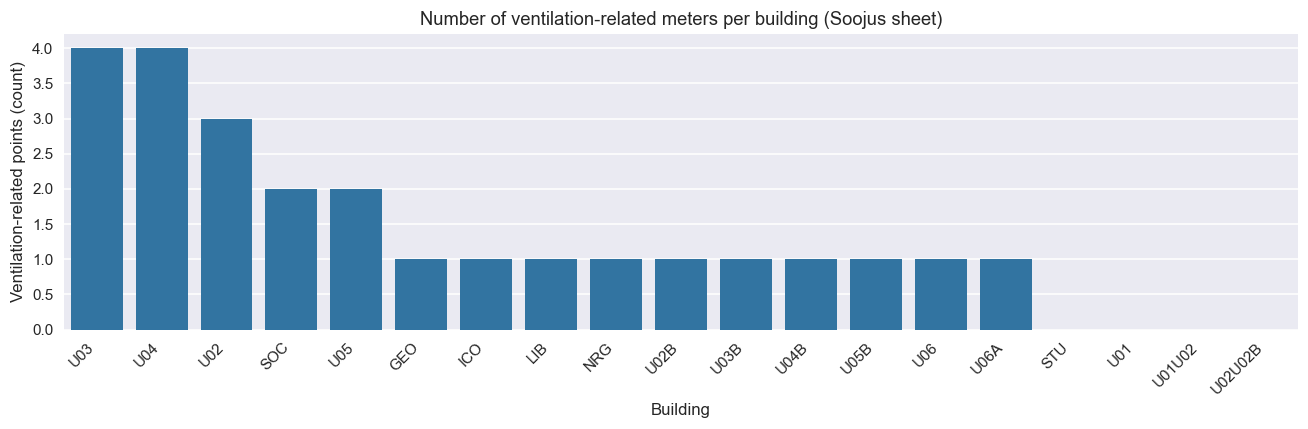

In [50]:
# Cell 1 — Campus meter overview (heat vs ventilation)

# Load heat-meter metadata from the overview Excel
heat_meta = pd.read_excel(OVERVIEW_FILE, sheet_name="Soojus")

# Quick sanity check on key identification columns
print("Heat overview columns:")
print(heat_meta[["Hoone", "building_abv", "System", "type"]].dtypes)
print()
print("Example systems and types (first 15 rows):")
display(
    heat_meta[["Hoone", "building_abv", "System", "type"]]
    .drop_duplicates()
    .sort_values(["Hoone", "System"])
    .head(15)
)

# Tag ventilation-related rows
vent_types = {"ventilatsioon", "ventküte", "õhkküte"}
heat_meta["is_vent_type"] = heat_meta["type"].isin(vent_types)
heat_meta["is_vent_in_system"] = heat_meta["System"].astype(str).str.contains("vent", case=False, na=False)
heat_meta["has_vent_flag"] = heat_meta["is_vent_type"] | heat_meta["is_vent_in_system"]

# Collapse repeated measurement rows to one row per physical meter (`point_id`) first.
point_level_heat_meta = (
    heat_meta
    .groupby(["building_abv", "point_id"], dropna=False)
    .agg(
        Hoone=(
            "Hoone",
            lambda s: " | ".join(sorted({str(v) for v in s.dropna() if str(v) != "nan"})),
        ),
        type=("type", lambda s: next((v for v in s.dropna() if str(v) != "nan"), np.nan)),
        has_vent_flag=("has_vent_flag", "max"),
    )
    .reset_index()
)

# Per-building summary: counts of distinct subsystem meters.
summary_by_building = (
    point_level_heat_meta
    .groupby("building_abv", dropna=False)
    .agg(
        Hoone=(
            "Hoone",
            lambda s: " | ".join(
                sorted({part.strip() for value in s.dropna() for part in str(value).split("|") if part.strip()})
            ),
        ),
        n_points=("point_id", "nunique"),
        n_vent_points=("has_vent_flag", "sum"),
        n_heat_points=("type", lambda s: s.isin(["küte", "radiaatorid"]).sum()),
        n_dhw_points=("type", lambda s: (s == "vesi").sum()),
    )
    .reset_index()
)

# Simple ventilation "richness" label for later use
summary_by_building["vent_class"] = pd.cut(
    summary_by_building["n_vent_points"],
    bins=[-0.5, 0.5, 2.5, 100],
    labels=["none", "basic", "rich"],
)
summary_by_building["has_multiple_hoone_labels"] = summary_by_building["Hoone"].str.contains(r"\|", na=False)

print("Per-building meter summary (sorted by ventilation points):")
display(summary_by_building.sort_values(["n_vent_points", "building_abv"], ascending=[False, True]))

if summary_by_building["has_multiple_hoone_labels"].any():
    print("\nConsolidated buildings with multiple raw `Hoone` labels into one `building_abv` row to avoid double-counting meters:")
    display(
        summary_by_building.loc[
            summary_by_building["has_multiple_hoone_labels"],
            ["building_abv", "Hoone", "n_points", "n_vent_points", "n_heat_points", "n_dhw_points"],
        ].sort_values("building_abv")
    )

# Bar plot: ventilation-related points per building
sns.barplot(
    data=summary_by_building.sort_values(["n_vent_points", "building_abv"], ascending=[False, True]),
    x="building_abv",
    y="n_vent_points",
    color="tab:blue",
)
plt.title("Number of ventilation-related meters per building (Soojus sheet)")
plt.xlabel("Building")
plt.ylabel("Ventilation-related points (count)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Summary of ventilation coverage (Soojus overview)

From the per-building summary table and plot above:

- **Most campus buildings have at least one explicit ventilation-related meter**, often several.
- **GEO, NRG, LIB, SOC, U02, U03, U04, U05, U06, ICO and their B/annex buildings** stand out with multiple ventilation or vent-heating points.
- A few combined systems (e.g. `U01U02`, `U02U02B`) appear as shared meters; these will need explicit handling later when attributing heat to a single building.
- The overview Excel also has an `Elekter` sheet with electrical meters; it is not used in the heat/ΔT analysis here but can be brought in later if electrical baselines are needed.

For later sections, the `vent_class` column (`none` / `basic` / `rich`) will be used to:

- Select **ventilation-rich buildings** for deeper ΔT and inertia analysis.
- Stratify comparisons of heat–weather relationships by whether a building has detailed ventilation metering or not.

## Cell 2 — District heating ΔT (supply–return) for GEO

**What this section does**

- Uses the *clean hourly dataset* for `GEO` to compute and visualise **district heating temperature difference**:
  - `ΔT_space = supply_temp_c − return_temp_c` for the main space-heating meter.
  - `ΔT_vent` and `ΔT_dhw` where ventilation and DHW meters have both supply and return temperatures.
- Produces basic time-series and scatter plots of **ΔT vs heat flow** and **ΔT vs outdoor temperature**.

**Why this matters for the thesis**

- In a district heating context, **ΔT is a direct efficiency and control indicator**: low ΔT at a given heat load usually means poor utilisation of the primary network and often hints at control or hydraulics issues.
- For inertia-aware modelling, ΔT helps separate **fast system-side effects** (valve control, ventilation loads) from **slow envelope/inertia effects**:
  - Buildings with very noisy or consistently low ΔT may be harder to control and could exhibit different dynamic responses.
  - Comparing ΔT patterns across buildings will inform which ones are good candidates for deeper inertia analysis.

GEO dataframe shape: (26304, 30)
Columns (first 20):
['bldg_space_heat_BHB02_mwh', 'bldg_space_heat_BHB02_supply_temp_c', 'bldg_space_heat_BHB02_return_temp_c', 'bldg_vent_heat_BHB03_mwh', 'bldg_vent_heat_BHB03_supply_temp_c', 'bldg_vent_heat_BHB03_return_temp_c', 'bldg_dhw_BHB04_mwh', 'bldg_dhw_BHB04_supply_temp_c', 'bldg_dhw_BHB04_return_temp_c', 'bldg_space_heat_BHB02_mwh_imputed', 'bldg_space_heat_BHB02_supply_temp_c_imputed', 'bldg_space_heat_BHB02_return_temp_c_imputed', 'bldg_vent_heat_BHB03_mwh_imputed', 'bldg_vent_heat_BHB03_supply_temp_c_imputed', 'bldg_vent_heat_BHB03_return_temp_c_imputed', 'bldg_dhw_BHB04_mwh_imputed', 'bldg_dhw_BHB04_supply_temp_c_imputed', 'bldg_dhw_BHB04_return_temp_c_imputed', 'bldg_space_heat_mwh', 'bldg_space_heat_deltaT_c']


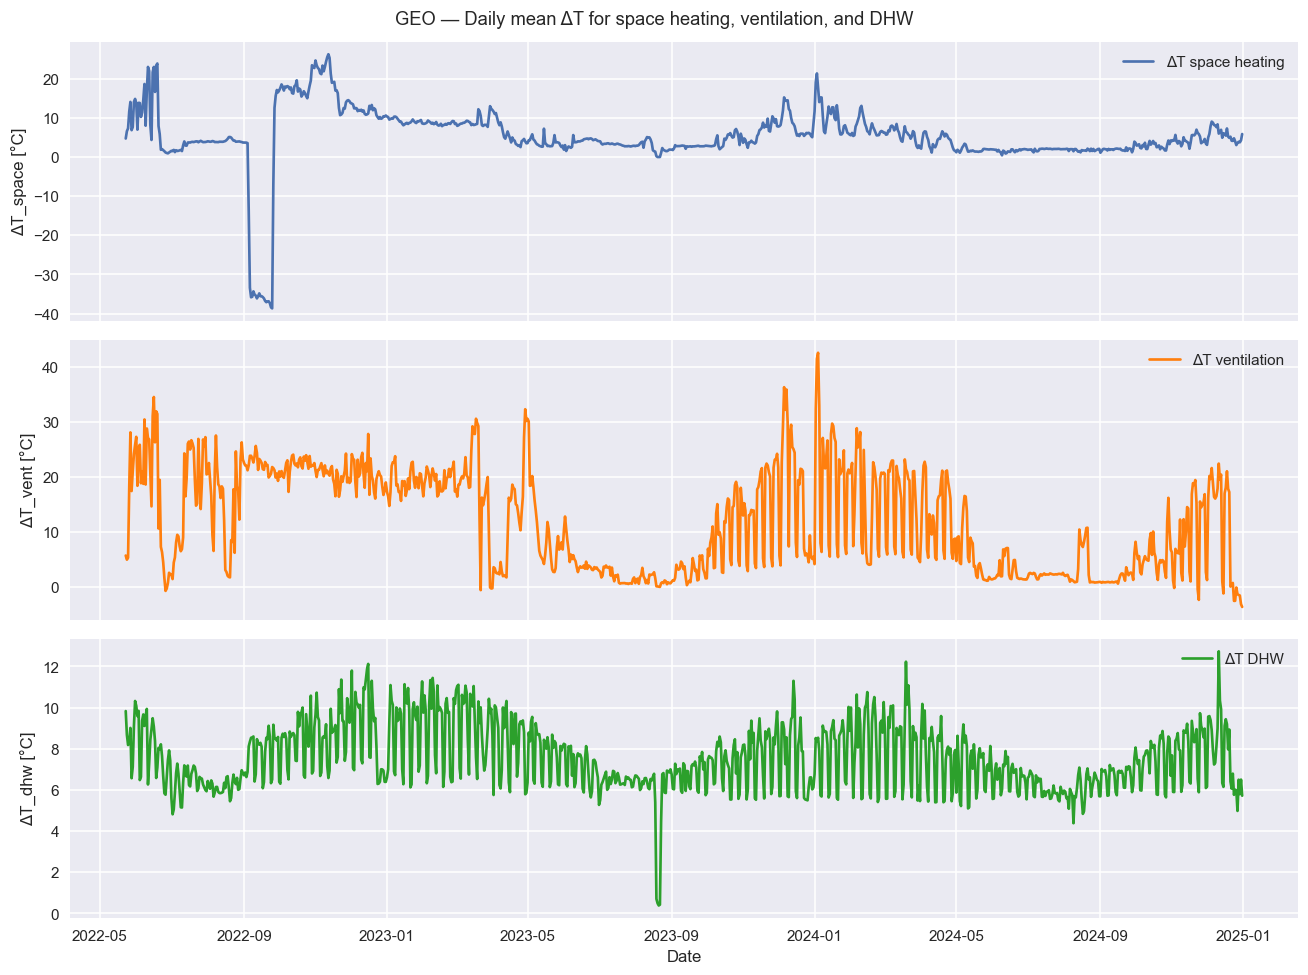

In [51]:
# Cell 2 — ΔT time series for GEO (space heating, ventilation, DHW)

# Load GEO clean hourly dataset
geo_path = CLEAN_DIR / "GEO_hourly_clean.csv"
geo = pd.read_csv(geo_path, index_col=0, parse_dates=True)

print(f"GEO dataframe shape: {geo.shape}")
print("Columns (first 20):")
print(list(geo.columns[:20]))

# Identify key columns for space heating, ventilation and DHW
space_cols = [
    "bldg_space_heat_BHB02_mwh",
    "bldg_space_heat_BHB02_supply_temp_c",
    "bldg_space_heat_BHB02_return_temp_c",
]
vent_cols = [
    "bldg_vent_heat_BHB03_mwh",
    "bldg_vent_heat_BHB03_supply_temp_c",
    "bldg_vent_heat_BHB03_return_temp_c",
]
dhw_cols = [
    "bldg_dhw_BHB04_mwh",
    "bldg_dhw_BHB04_supply_temp_c",
    "bldg_dhw_BHB04_return_temp_c",
]

missing_any = [c for c in space_cols + vent_cols + dhw_cols if c not in geo.columns]
if missing_any:
    print("WARNING: Missing expected GEO columns:", missing_any)

# Compute ΔT where both supply and return are available
geo["deltaT_space"] = (
    geo.get("bldg_space_heat_BHB02_supply_temp_c")
    - geo.get("bldg_space_heat_BHB02_return_temp_c")
)
geo["deltaT_vent"] = (
    geo.get("bldg_vent_heat_BHB03_supply_temp_c")
    - geo.get("bldg_vent_heat_BHB03_return_temp_c")
)
geo["deltaT_dhw"] = (
    geo.get("bldg_dhw_BHB04_supply_temp_c")
    - geo.get("bldg_dhw_BHB04_return_temp_c")
)

# Simple seasonal view: daily mean ΔT for space heating
geo_daily = geo.resample("D").mean(numeric_only=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(geo_daily.index, geo_daily["deltaT_space"], label="ΔT space heating")
axes[0].set_ylabel("ΔT_space [°C]")
axes[0].legend(loc="upper right")

axes[1].plot(geo_daily.index, geo_daily["deltaT_vent"], label="ΔT ventilation", color="tab:orange")
axes[1].set_ylabel("ΔT_vent [°C]")
axes[1].legend(loc="upper right")

axes[2].plot(geo_daily.index, geo_daily["deltaT_dhw"], label="ΔT DHW", color="tab:green")
axes[2].set_ylabel("ΔT_dhw [°C]")
axes[2].set_xlabel("Date")
axes[2].legend(loc="upper right")

fig.suptitle("GEO — Daily mean ΔT for space heating, ventilation, and DHW")
plt.tight_layout()
plt.show()

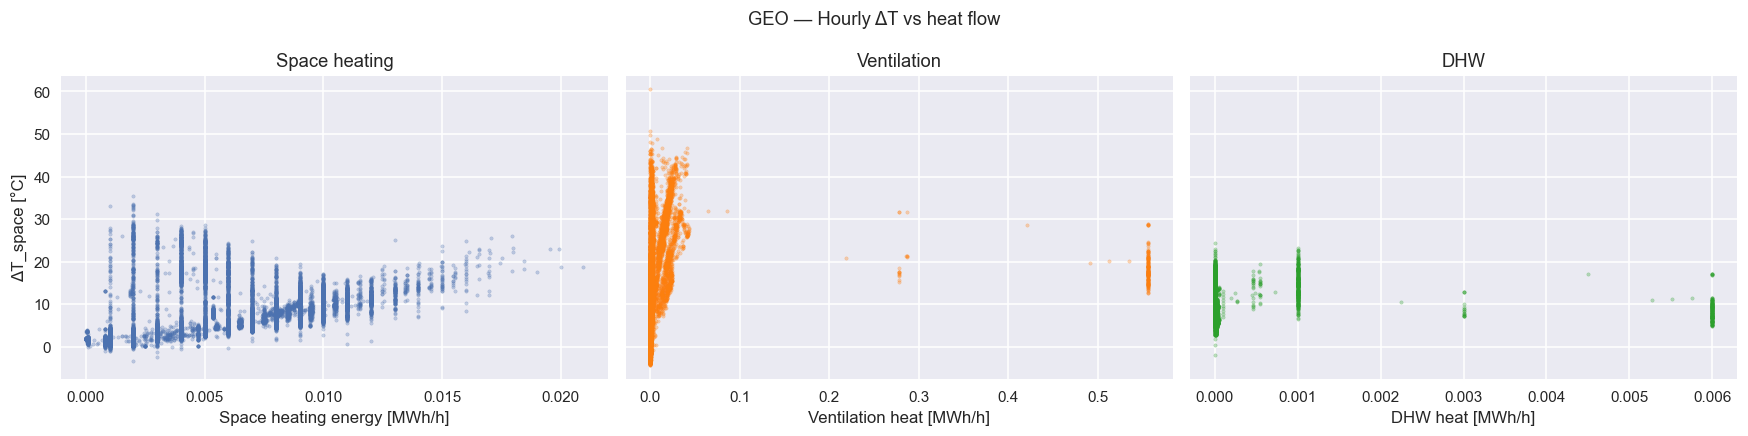

In [52]:
# Cell 2b — GEO ΔT vs heat flow (hourly scatter)

# Restrict to heating season to avoid division by very small loads
geo_h = geo.copy()

# Keep only hours with at least a small positive heat flow
geo_h = geo_h[geo_h["bldg_space_heat_BHB02_mwh"].fillna(0) > 0.0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

axes[0].scatter(
    geo_h["bldg_space_heat_BHB02_mwh"], geo_h["deltaT_space"],
    s=5, alpha=0.3
)
axes[0].set_xlabel("Space heating energy [MWh/h]")
axes[0].set_ylabel("ΔT_space [°C]")
axes[0].set_title("Space heating")

axes[1].scatter(
    geo_h["bldg_vent_heat_BHB03_mwh"], geo_h["deltaT_vent"],
    s=5, alpha=0.3, color="tab:orange"
)
axes[1].set_xlabel("Ventilation heat [MWh/h]")
axes[1].set_title("Ventilation")

axes[2].scatter(
    geo_h["bldg_dhw_BHB04_mwh"], geo_h["deltaT_dhw"],
    s=5, alpha=0.3, color="tab:green"
)
axes[2].set_xlabel("DHW heat [MWh/h]")
axes[2].set_title("DHW")

fig.suptitle("GEO — Hourly ΔT vs heat flow")
plt.tight_layout()
plt.show()

### First ΔT observations for GEO

After running the ΔT cells for `GEO` you should see:

- **Daily ΔT patterns** for space heating, ventilation, and DHW that:
  - Stay within physically reasonable ranges for district heating (typically tens of °C in winter, smaller in summer).
  - Show clear **seasonal structure**: larger ΔT in colder months, lower and noisier ΔT in summer.
- **Scatter plots of ΔT vs heat flow** where:
  - Space-heating ΔT generally increases with hourly heat flow up to a point, then either saturates or becomes more scattered.
  - Ventilation and DHW ΔT may behave differently (e.g. flatter, more constant ΔT) depending on control strategies.

From an inertia perspective, GEO will later serve as a **reference building** when comparing ΔT patterns, heat–temperature slopes, and dynamic response metrics to other campus buildings.

### Heating-season definition for ΔT analysis

In the portfolio ΔT analysis below, the **heating season** is defined using weather data rather than only calendar months:

- We load the combined campus weather file and take the average of COP and KKP outdoor temperatures where available.
- Hours with **effective outdoor temperature below 10 °C** are treated as potential heating-season hours.
- When computing per-building ΔT statistics we restrict to these hours, which better matches actual district heating operation than a rigid November–March calendar window.

In [53]:
# Weather-based heating season mask for ΔT analysis

weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"])
weather = weather.set_index("datetime").sort_index()

# Effective outdoor temperature: prefer COP, then KKP
eff_temp = weather["COP_temp_c"].combine_first(weather["KKP_temp_c"])

HEATING_INDEX = eff_temp[eff_temp < 10.0].index
print(f"Heating-season hours (T_out < 10°C): {len(HEATING_INDEX)}")

Heating-season hours (T_out < 10°C): 21863


## Cell 2c — Portfolio-wide ΔT summary across buildings

**What this section does**

- Extends the GEO-only ΔT view to a **portfolio-wide analysis**:
  - For each campus building with suitable meter data, computes heating-season statistics of ΔT for space heating, ventilation, and DHW.
  - Aggregates these into a per-building table.
  - Visualises how ΔT performance varies across buildings and by ventilation richness (`vent_class`).

**Why this matters for the thesis**

- District-heating ΔT is primarily an **efficiency and control** metric, but it also constrains how much of the delivered heat can be “parked” in the building’s thermal mass.
- A portfolio-wide view lets you:
  - Identify **ΔT-problematic** buildings that may mask inertia effects.
  - See whether **ventilation-rich** buildings systematically behave differently in terms of ΔT.
  - Prepare simple ΔT features (e.g. median ΔT, share of low-ΔT hours) for later correlation with inertia-aware metrics.

[ΔT] ICO: multiple space meters detected, using the first one: bldg_space_heat_BHB01
[ΔT] SOC: multiple vent meters detected, using the first one: bldg_vent_heat_BHB03
[ΔT] U02: multiple vent meters detected, using the first one: bldg_vent_heat_BHB03
[ΔT] U03: multiple vent meters detected, using the first one: bldg_vent_heat_BHB03
Per-building ΔT summary (space heating, heating season T_out < 10 °C):


,building_abv,deltaT_space_median,deltaT_space_p10,deltaT_space_p90,share_low_deltaT_space,deltaT_vent_median,deltaT_vent_p10,deltaT_vent_p90,share_low_deltaT_vent,deltaT_dhw_median,deltaT_dhw_p10,deltaT_dhw_p90,share_low_deltaT_dhw,vent_class
3,SOC,4.754025,1.849911,8.351100,0.995829,9.336410,3.944147,17.040278,0.840704,36.666056,12.603030,44.902378,0.129464,basic
6,U02B,6.101667,2.678000,9.704763,0.999916,31.800000,27.351333,37.055000,0.003578,NaN,NaN,NaN,NaN,basic
2,LIB,6.670000,3.050000,9.858958,0.999267,1.695000,0.490000,4.900600,1.000000,35.326667,19.506605,40.843820,0.036963,basic
8,U03B,6.880000,2.720000,9.899333,0.998043,18.349491,10.428875,25.825500,0.310935,36.648750,31.010333,40.819667,0.000000,basic
10,U06,7.410000,3.378400,12.090000,0.972655,6.510000,2.970000,10.339667,0.996264,38.181667,31.629143,41.261857,0.000000,basic
0,GEO,7.657000,3.160000,14.728000,0.904195,22.960000,11.722000,33.349680,0.207887,8.395732,5.894769,11.079362,0.962366,basic
1,ICO,7.920000,3.742000,12.410000,0.971789,4.900000,0.682000,18.508000,0.863309,32.130000,25.930000,35.590000,0.030999,basic
4,U01,10.453333,5.080000,13.610000,0.973026,-62.370750,-73.081800,-47.195150,1.000000,43.202500,29.624000,51.213654,0.001505,none
7,U03,14.786667,6.970000,20.170353,0.523203,13.400000,7.805333,18.846667,0.655738,44.630000,36.326000,49.139333,0.001543,rich
5,U02,NaN,NaN,NaN,NaN,5.760000,1.380000,26.177500,0.722309,34.993333,28.004000,38.300000,0.009002,rich


Buildings with median space-heating ΔT < 15 °C: 9 / 11

Mean of per-building median ΔT_space by ventilation richness:


,mean_median_deltaT_space
vent_class,
none,10.453333
basic,6.770385
rich,14.786667


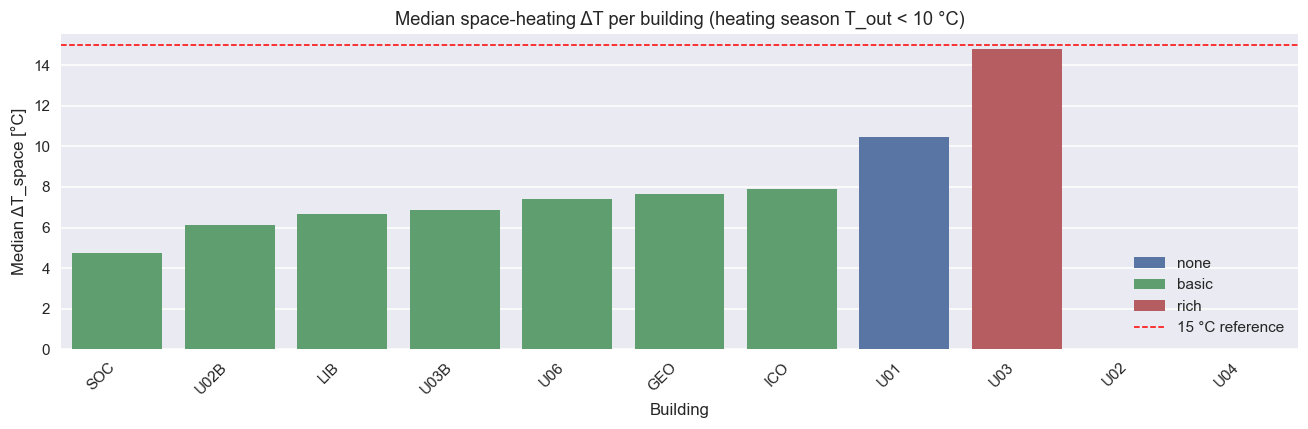

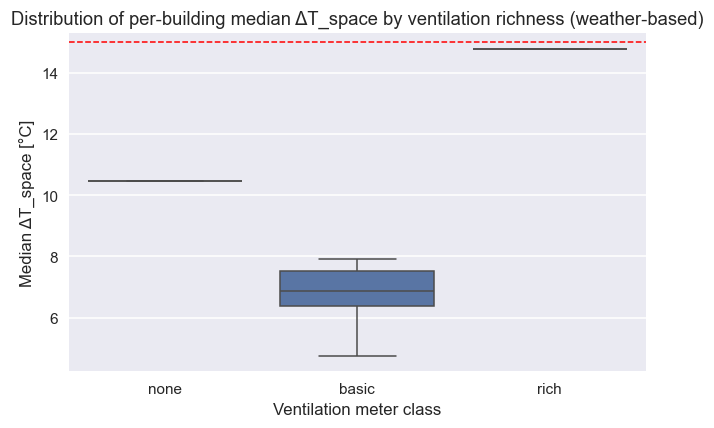

In [54]:
# Cell 2c (updated) — Per-building ΔT statistics using weather-based heating season

from typing import Optional, Dict, Any


def compute_deltaT_stats_for_building_v2(building_abv: str) -> Optional[Dict[str, Any]]:
    """Weather-based heating-season ΔT statistics for one building.

    - Loads the building's clean hourly dataset (if available).
    - Detects meter triplets with supply/return temperatures and energy (MWh).
    - For each of space heating, ventilation, and DHW (if present), computes:
      - Median ΔT during hours where effective T_out < 10 °C.
      - Share of hours with low ΔT (< 15 °C) at non-trivial load.
    """
    path = CLEAN_DIR / f"{building_abv}_hourly_clean.csv"
    if not path.exists():
        return None

    df = pd.read_csv(path, index_col=0, parse_dates=True)
    if df.empty:
        return None

    supply_cols = [c for c in df.columns if c.endswith("_supply_temp_c")]
    triplets = []  # (base, energy_col, supply_col, return_col)

    for sc in supply_cols:
        base = sc[: -len("_supply_temp_c")]
        rc = base + "_return_temp_c"
        ec = base + "_mwh"
        if rc in df.columns and ec in df.columns:
            triplets.append((base, ec, sc, rc))

    if not triplets:
        return None

    stats: Dict[str, Any] = {"building_abv": building_abv}

    # Heating season: hours where effective outdoor temperature is below 10 °C.
    # If the global HEATING_INDEX is not available, fall back to a Nov–Mar calendar window.
    if "HEATING_INDEX" in globals():
        heating_mask = df.index.isin(HEATING_INDEX)
        heating_season = df.loc[heating_mask].copy()
    else:
        heating_season = df[(df.index.month >= 11) | (df.index.month <= 3)].copy()

    for category, keyword in [("space", "space_heat"), ("vent", "vent_heat"), ("dhw", "dhw")]:
        candidates = [t for t in triplets if keyword in t[0]]
        if not candidates:
            continue

        if len(candidates) > 1:
            print(f"[ΔT] {building_abv}: multiple {category} meters detected, using the first one: {candidates[0][0]}")

        base, ec, sc, rc = candidates[0]
        delta_col = base + "_deltaT_c"
        heating_season[delta_col] = df[sc] - df[rc]

        # Restrict to hours with non-trivial load
        hs_nonzero = heating_season[heating_season[ec].fillna(0) > 0.001]
        vals = hs_nonzero[delta_col].dropna()
        if vals.empty:
            continue

        stats[f"deltaT_{category}_median"] = vals.median()
        stats[f"deltaT_{category}_p10"] = vals.quantile(0.10)
        stats[f"deltaT_{category}_p90"] = vals.quantile(0.90)
        stats[f"share_low_deltaT_{category}"] = (vals < 15.0).mean()

    if not any(k.startswith("deltaT_") for k in stats.keys()):
        return None

    return stats


# Build portfolio-level ΔT summary (weather-based heating season)
rows_v2: list[Dict[str, Any]] = []
for b in CAMPUS_BUILDINGS:
    s = compute_deltaT_stats_for_building_v2(b)
    if s is not None:
        rows_v2.append(s)

if not rows_v2:
    print("No ΔT statistics could be computed — check cleaned datasets and column names.")
else:
    deltaT_summary_v2 = pd.DataFrame(rows_v2)

    if "summary_by_building" in globals():
        deltaT_summary_v2 = deltaT_summary_v2.merge(
            summary_by_building[["building_abv", "vent_class"]].drop_duplicates("building_abv"),
            on="building_abv",
            how="left",
        )

    print("Per-building ΔT summary (space heating, heating season T_out < 10 °C):")
    display(
        deltaT_summary_v2
        .sort_values("deltaT_space_median", na_position="last")
    )

    if "deltaT_space_median" in deltaT_summary_v2.columns:
        n_bldgs = len(deltaT_summary_v2)
        n_below_15 = int((deltaT_summary_v2["deltaT_space_median"] < 15.0).sum())
        print(f"Buildings with median space-heating ΔT < 15 °C: {n_below_15} / {n_bldgs}")

        if "vent_class" in deltaT_summary_v2.columns:
            print("\nMean of per-building median ΔT_space by ventilation richness:")
            display(
                deltaT_summary_v2
                .groupby("vent_class", observed=False)["deltaT_space_median"]
                .mean()
                .to_frame("mean_median_deltaT_space")
            )

    # Bar plot: median space-heating ΔT by building, coloured by vent_class
    if "deltaT_space_median" in deltaT_summary_v2.columns:
        order = (
            deltaT_summary_v2
            .sort_values("deltaT_space_median", na_position="last")
            ["building_abv"]
            .tolist()
        )

        plt.figure(figsize=(12, 4))
        sns.barplot(
            data=deltaT_summary_v2,
            x="building_abv",
            y="deltaT_space_median",
            hue="vent_class",
            order=order,
        )
        plt.axhline(15, color="red", linestyle="--", linewidth=1, label="15 °C reference")
        plt.title("Median space-heating ΔT per building (heating season T_out < 10 °C)")
        plt.xlabel("Building")
        plt.ylabel("Median ΔT_space [°C]")
        plt.xticks(rotation=45, ha="right")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()

        if "vent_class" in deltaT_summary_v2.columns:
            plt.figure(figsize=(6, 4))
            sns.boxplot(
                data=deltaT_summary_v2,
                x="vent_class",
                y="deltaT_space_median",
                order=["none", "basic", "rich"],
            )
            plt.axhline(15, color="red", linestyle="--", linewidth=1, label="15 °C reference")
            plt.title("Distribution of per-building median ΔT_space by ventilation richness (weather-based)")
            plt.xlabel("Ventilation meter class")
            plt.ylabel("Median ΔT_space [°C]")
            plt.tight_layout()
            plt.show()


Per-building ΔT summary (space heating, heating season Nov–Mar):


,building_abv,deltaT_space_median,deltaT_space_p10,deltaT_space_p90,share_low_deltaT_space,deltaT_vent_median,deltaT_vent_p10,deltaT_vent_p90,share_low_deltaT_vent,deltaT_dhw_median,deltaT_dhw_p10,deltaT_dhw_p90,share_low_deltaT_dhw,vent_class
3,SOC,5.375000,3.064503,8.925988,0.994342,11.055581,4.832700,18.232852,0.785493,39.281089,7.019667,45.953500,0.165430,basic
6,U02B,6.910000,3.953667,10.234833,0.999883,31.780000,27.679000,36.580000,0.000000,NaN,NaN,NaN,NaN,basic
2,LIB,7.530000,4.470000,10.311917,0.998968,2.030000,0.610000,5.469618,1.000000,36.091667,20.521699,40.959822,0.033434,basic
8,U03B,7.686667,4.530000,10.442667,0.997421,20.071667,11.049333,26.660000,0.257583,37.315000,31.937000,41.092000,0.000000,basic
0,GEO,8.270000,4.190000,13.850751,0.921749,23.360000,11.359000,34.103220,0.222706,8.395732,5.894769,11.079362,0.962366,basic
10,U06,8.458333,3.974833,12.974000,0.960422,7.270000,4.510000,10.947000,0.994296,39.166667,33.706986,41.477333,0.000000,basic
1,ICO,9.040000,5.500000,13.280000,0.960540,5.250000,0.770000,19.882000,0.849382,33.375000,29.109000,36.182000,0.015385,basic
4,U01,11.231667,7.975500,13.800000,0.971385,-63.131083,-72.161633,-51.967500,1.000000,44.660000,30.693333,52.250000,0.002040,none
7,U03,15.915000,11.861667,21.120000,0.370669,14.080000,9.330333,19.353000,0.602100,45.531667,37.652500,49.480000,0.001886,rich
5,U02,NaN,NaN,NaN,NaN,8.135000,1.512000,28.400430,0.659854,35.210833,29.471500,37.434700,0.007737,rich


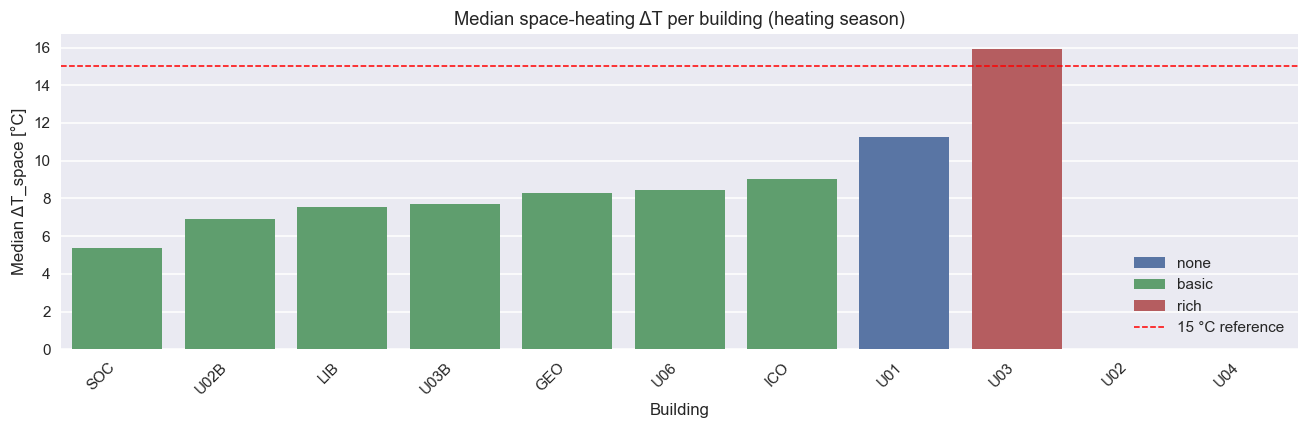

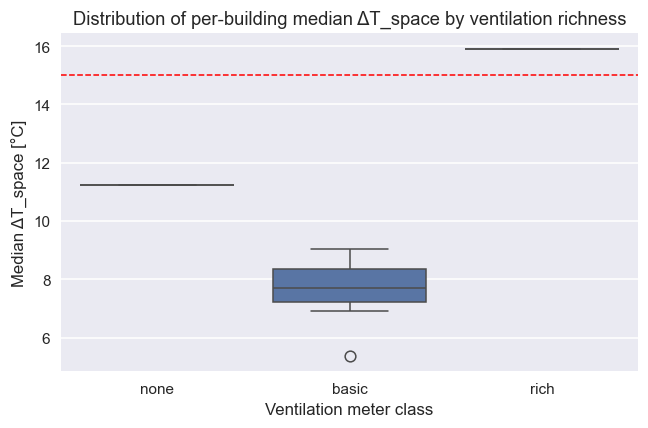

In [55]:
# Cell 2c — Per-building ΔT statistics over the portfolio

from typing import Optional, Dict, Any


def compute_deltaT_stats_for_building(building_abv: str) -> Optional[Dict[str, Any]]:
    """Compute simple heating-season ΔT statistics for one building.

    - Loads the building's clean hourly dataset (if available).
    - Detects meter triplets with supply/return temperatures and energy (MWh).
    - For each of space heating, ventilation, and DHW (if present), computes:
      - Median ΔT during the heating season (months Nov–Mar).
      - Share of hours with low ΔT (< 15 °C) at non-trivial load.
    """
    path = CLEAN_DIR / f"{building_abv}_hourly_clean.csv"
    if not path.exists():
        return None

    df = pd.read_csv(path, index_col=0, parse_dates=True)
    if df.empty:
        return None

    supply_cols = [c for c in df.columns if c.endswith("_supply_temp_c")]
    triplets = []  # (base, energy_col, supply_col, return_col)

    for sc in supply_cols:
        base = sc[: -len("_supply_temp_c")]
        rc = base + "_return_temp_c"
        ec = base + "_mwh"
        if rc in df.columns and ec in df.columns:
            triplets.append((base, ec, sc, rc))

    if not triplets:
        return None

    stats: Dict[str, Any] = {"building_abv": building_abv}

    # Define a simple "heating season" as Nov–Mar (can be tightened later with weather-based filters)
    heating_season = df[(df.index.month >= 11) | (df.index.month <= 3)].copy()

    for category, keyword in [("space", "space_heat"), ("vent", "vent_heat"), ("dhw", "dhw")]:
        candidates = [t for t in triplets if keyword in t[0]]
        if not candidates:
            continue

        base, ec, sc, rc = candidates[0]  # take the first matching triplet per category
        delta_col = base + "_deltaT_c"
        heating_season[delta_col] = df[sc] - df[rc]

        # Restrict to hours with non-trivial load
        hs_nonzero = heating_season[heating_season[ec].fillna(0) > 0.001]
        vals = hs_nonzero[delta_col].dropna()
        if vals.empty:
            continue

        stats[f"deltaT_{category}_median"] = vals.median()
        stats[f"deltaT_{category}_p10"] = vals.quantile(0.10)
        stats[f"deltaT_{category}_p90"] = vals.quantile(0.90)
        stats[f"share_low_deltaT_{category}"] = (vals < 15.0).mean()

    # If no category produced any stats, skip this building
    if not any(k.startswith("deltaT_") for k in stats.keys()):
        return None

    return stats


# Build portfolio-level ΔT summary
rows: list[Dict[str, Any]] = []
for b in CAMPUS_BUILDINGS:
    s = compute_deltaT_stats_for_building(b)
    if s is not None:
        rows.append(s)

if not rows:
    print("No ΔT statistics could be computed — check cleaned datasets and column names.")
else:
    deltaT_summary = pd.DataFrame(rows)

    # Attach ventilation richness class from the earlier overview, if available
    if "summary_by_building" in globals():
        deltaT_summary = deltaT_summary.merge(
            summary_by_building[["building_abv", "vent_class"]],
            on="building_abv",
            how="left",
        )

    print("Per-building ΔT summary (space heating, heating season Nov–Mar):")
    display(
        deltaT_summary
        .sort_values("deltaT_space_median", na_position="last")
    )

    # Bar plot: median space-heating ΔT by building, coloured by vent_class
    if "deltaT_space_median" in deltaT_summary.columns:
        order = (
            deltaT_summary
            .sort_values("deltaT_space_median", na_position="last")
            ["building_abv"]
            .tolist()
        )

        plt.figure(figsize=(12, 4))
        sns.barplot(
            data=deltaT_summary,
            x="building_abv",
            y="deltaT_space_median",
            hue="vent_class",
            order=order,
        )
        plt.axhline(15, color="red", linestyle="--", linewidth=1, label="15 °C reference")
        plt.title("Median space-heating ΔT per building (heating season)")
        plt.xlabel("Building")
        plt.ylabel("Median ΔT_space [°C]")
        plt.xticks(rotation=45, ha="right")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()

        # Boxplot of per-building median ΔT by ventilation richness
        if "vent_class" in deltaT_summary.columns:
            plt.figure(figsize=(6, 4))
            sns.boxplot(
                data=deltaT_summary,
                x="vent_class",
                y="deltaT_space_median",
                order=["none", "basic", "rich"],
            )
            plt.axhline(15, color="red", linestyle="--", linewidth=1, label="15 °C reference")
            plt.title("Distribution of per-building median ΔT_space by ventilation richness")
            plt.xlabel("Ventilation meter class")
            plt.ylabel("Median ΔT_space [°C]")
            plt.tight_layout()
            plt.show()

### Portfolio-wide ΔT observations and open questions

With the portfolio ΔT summary in place, you can now:

- **Rank buildings** by median space-heating ΔT and quickly see which ones spend a large share of heating-season hours below the 15 °C reference line (potential ΔT problems).
- **Compare ΔT across `vent_class` groups**: if `rich` buildings tend to have systematically higher or more stable ΔT than `basic`/`none`, this hints at different subsystem design or control strategies.
- Use `share_low_deltaT_space` and related statistics as **candidate features** when you later:
  - Analyse inertia-aware metrics (e.g. step-response time constants, night-setback behaviour).
  - Decide which buildings are most promising for deeper inertia modelling vs which are dominated by control/network issues.

Open questions to keep in mind (for later sections):

- Do buildings with consistently low ΔT also show noisier or less interpretable inertia metrics?
- Is there any alignment between ΔT performance and **EHR energy marks** or **heated area** once those features are added?

## Cell 3 — EHR coverage and building-level features

This section focuses on **EHR metadata coverage** for the campus buildings and prepares a **tidy feature table** that can later be joined to heat time-series data.

What we do here:

- Load preprocessed EHR summary tables in `data/ehr-building-data/` (built from the raw JSON dumps per building).
- Map EHR entries to campus building identifiers (e.g. `U01`, `U02 (+U02B)`, `LIB`, `GEO`).
- Quantify **coverage of heated area and energy marks** (energy classes) across the portfolio.
- **Energiamärgised (energy marks)**: Explicit check of which buildings have an energy class/certificate in EHR — in the current extract only **three** buildings have this (U05, U06+U06A, ICT); the rest lack energiamärgis in EHR, which limits energy-class-based modelling for most of the portfolio.
- Export a compact, per-building **EHR feature table** (heated area, energy class, selected technical fields) for downstream modelling notebooks.

EHR summary file exists : True
EHR certificates file   : True

EHR summary shape: (16, 75)
Columns (summary): ['campus_code', 'ehr_code', 'name', 'address', 'building_type', 'kaos_code', 'status', 'first_use_year', 'height_m', 'width_m', 'length_m', 'gross_volume_m3'] ...
EHR certificates shape: (3, 8)

First rows of EHR building summary (campus ↔ EHR linkage):


,campus_code,ehr_code,name,address,heated_area_m2,energy_class,has_certificate
0,U01,101026153,õppehoone nr 1,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",4088.7,NaN,False
1,U02 (+U02B),101026150,TTÜ õppehoone nr 2,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",24136.0,NaN,False
2,U03 (+U03B),101026151,õppehoone nr 3,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",5908.0,NaN,False
3,U04,101026152,õppehoone nr 4,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",5777.1,NaN,False
4,U04B,101026655,õppehoone n 4B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",NaN,NaN,False
5,U05,101026146,TTÜ teadus-õppehoone V korpus galeriidega,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",5550.0,E,True
6,U05B,101026656,õppehoone nr 5B,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",NaN,NaN,False
7,U06 (+U06A),101026149,õppehoone nr 6,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",12841.2,D,True
8,GEO,120296180,TTÜ HOONETEKOMPLEKSI III JA IV KORPUSE VAHEHOO...,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",898.2,NaN,False
9,STU,120599499,külmaseade,"Harju maakond, Tallinn, Mustamäe linnaosa, Ehi...",NaN,NaN,False



Campus buildings with any EHR entry:


,building_abv,has_ehr
0,GEO,True
1,ICO,True
2,LIB,True
3,SOC,True
4,STU,True
5,U01,True
6,U01U02,False
7,U02,True
8,U02B,True
9,U03,True



EHR coverage summary across campus buildings:


...

Energiamärgised (energy marks) in EHR:
  Buildings with energy class / certificate: 3 of 16 EHR rows (19%)
  → Only 3 building(s) have energiamärgis in the current EHR extract (see list below).
  Buildings that have energiamärgis:


,campus_code,energy_class,certificate_date,document_type
5,U05,E,2011-05-18,Energiaarvutusel põhineva energiamärgise teatis
7,U06 (+U06A),D,2011-12-19,Energiaarvutusel põhineva energiamärgise teatis
13,ICT,C,2011-04-27,Ehitise aadressi korrastuse teatis


  Buildings in EHR summary without energiamärgis: 13
   ['U01', 'U02 (+U02B)', 'U03 (+U03B)', 'U04', 'U04B', 'U05B', 'GEO', 'STU', 'NRG', 'LIB', 'SOC', 'ICO', 'TIM']
  → For heat modelling, energy class will only be available for the few buildings above; rest are missing.
  Summary: only 3 building(s) with energiamärgis — ['U05', 'U06 (+U06A)', 'ICT']

Tidy EHR feature table (first 10 rows):


,campus_code,ehr_code,heated_area_m2,energy_class,building_type,usage_non_res_share_of_heated,building_age_years,ventilation_type,cooling_system,heated_area_missing,has_energy_class
0,U01,101026153,4088.7,NaN,Muu haridus- või teadushoone,0.983,58,NaN,NaN,False,False
1,U02 (+U02B),101026150,24136.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",0.223,59,NaN,NaN,False,False
2,U03 (+U03B),101026151,5908.0,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",1.209,60,soojustagastusega ventilatsioon,lokaalne jahutus,False,False
3,U04,101026152,5777.1,NaN,"Ülikooli, rakenduskõrgkooli õppehoone",1.000,61,NaN,NaN,False,False
4,U04B,101026655,NaN,NaN,Muu haridus- või teadushoone,NaN,40,NaN,NaN,True,False
5,U05,101026146,5550.0,E,"Ülikooli, rakenduskõrgkooli õppehoone",1.000,62,NaN,NaN,False,True
6,U05B,101026656,NaN,NaN,Muu haridus- või teadushoone,NaN,26,NaN,NaN,True,False
7,U06 (+U06A),101026149,12841.2,D,"Ülikooli, rakenduskõrgkooli õppehoone",1.000,40,soojustagastusega ventilatsioon,lokaalne jahutus,False,True
8,GEO,120296180,898.2,NaN,Muu haridus- või teadushoone,1.015,20,NaN,NaN,False,False
9,STU,120599499,NaN,NaN,Muu erihoone,NaN,15,NaN,NaN,True,False



Saved tidy EHR feature table to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean/ehr_building_features.csv


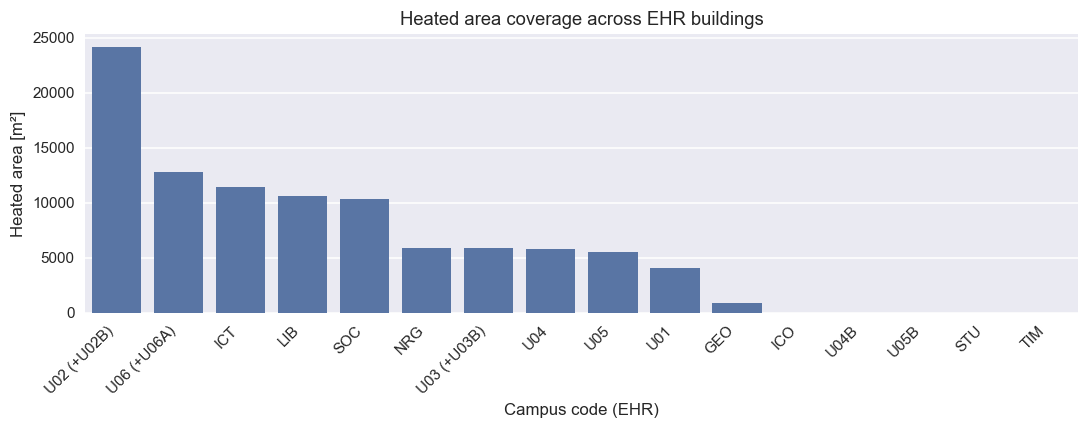

In [ ]:
# Cell 3a — Load and inspect EHR summary tables

from pathlib import Path

# EHR summary CSVs (already extracted from raw JSONs in this project)
EHR_SUMMARY_FILE = EHR_DIR / "ehr_building_summary.csv"
EHR_CERT_FILE    = EHR_DIR / "ehr_energy_certificates.csv"

print("EHR summary file exists :", EHR_SUMMARY_FILE.exists())
print("EHR certificates file   :", EHR_CERT_FILE.exists())

ehr_summary = pd.read_csv(EHR_SUMMARY_FILE)
ehr_certs   = pd.read_csv(EHR_CERT_FILE)

print("\nEHR summary shape:", ehr_summary.shape)
print("Columns (summary):", list(ehr_summary.columns)[:12], "...")
print("EHR certificates shape:", ehr_certs.shape)

# Quick peek at the main identifier linkage
print("\nFirst rows of EHR building summary (campus ↔ EHR linkage):")
display(ehr_summary[[
    "campus_code", "ehr_code", "name", "address", "heated_area_m2", "energy_class", "has_certificate"
]].head(10))

# Cell 3b — Map EHR coverage to campus building list

# Helper: for each campus building in CAMPUS_BUILDINGS, check whether any EHR entry references it
unique_ehr_keys = ehr_summary["campus_code"].astype(str).unique().tolist()


def has_ehr_entry(building_abv: str) -> bool:
    """Return True if any campus_code in the EHR summary appears to describe this building.

    This is intentionally permissive for composite keys like "U02 (+U02B)" or "U06 (+U06A)",
    where a single EHR object covers multiple campus time-series buildings.
    """

    b = building_abv.strip()
    for key in unique_ehr_keys:
        if b == key:
            return True
        # Allow composite keys such as "U02 (+U02B)" or "U03 (+U03B)"
        if b in key:
            return True
    return False


campus_ehr_coverage = (
    pd.DataFrame({"building_abv": CAMPUS_BUILDINGS})
    .assign(has_ehr=lambda df: df["building_abv"].apply(has_ehr_entry))
)

print("\nCampus buildings with any EHR entry:")
display(campus_ehr_coverage)

print("\nEHR coverage summary across campus buildings:")
coverage_counts = campus_ehr_coverage["has_ehr"].value_counts().rename_axis("has_ehr").reset_index(name="n_buildings")
coverage_counts["share"] = coverage_counts["n_buildings"] / len(CAMPUS_BUILDINGS)
display(coverage_counts)

# Cell 3c — Coverage of heated area and energy class (portfolio-level)

# Basic coverage indicators at the EHR summary level
ehr_summary["has_heated_area"] = ehr_summary["heated_area_m2"].fillna(0) > 0

for col in ["energy_class", "has_certificate"]:
    if col not in ehr_summary.columns:
        ehr_summary[col] = pd.NA

coverage_table = pd.DataFrame(
    {
        "metric": [
            "EHR rows (buildings)",
            "With heated_area_m2 > 0",
            "With non-missing energy_class",
            "With has_certificate == True",
        ],
        "count": [
            len(ehr_summary),
            ehr_summary["has_heated_area"].sum(),
            ehr_summary["energy_class"].notna().sum(),
            ehr_summary["has_certificate"].fillna(False).astype(bool).sum(),
        ],
    }
)
coverage_table["share"] = coverage_table["count"] / coverage_table.loc[0, "count"]

print("\nPortfolio-level EHR coverage for heated area and energy marks:")
display(coverage_table)

# Cell 3c2 — Energiamärgised (energy marks): explicit check per building
# Only a few campus buildings have energy certificates in EHR; list them and flag the gap.

has_energy_mark = (
    ehr_summary["energy_class"].notna()
    & (ehr_summary["energy_class"].astype(str).str.strip().str.len() > 0)
)
cols_mark = ["campus_code", "energy_class"]
for c in ["certificate_date", "document_type"]:
    if c in ehr_summary.columns:
        cols_mark.append(c)
ehr_with_mark = ehr_summary.loc[has_energy_mark, cols_mark].copy()

n_with_mark = len(ehr_with_mark)
n_total_ehr = len(ehr_summary)
print("Energiamärgised (energy marks) in EHR:")
print(f"  Buildings with energy class / certificate: {n_with_mark} of {n_total_ehr} EHR rows ({100 * n_with_mark / max(1, n_total_ehr):.0f}%)")
if n_with_mark > 0:
    print(f"  → Only {n_with_mark} building(s) have energiamärgis in the current EHR extract (see list below).")
print("  Buildings that have energiamärgis:")
if ehr_with_mark.empty:
    print("    (none)")
else:
    display(ehr_with_mark)

buildings_without_mark = ehr_summary.loc[~has_energy_mark, "campus_code"].tolist()
print(f"  Buildings in EHR summary without energiamärgis: {len(buildings_without_mark)}")
print("  ", buildings_without_mark)
print("  → For heat modelling, energy class will only be available for the few buildings above; rest are missing.")
if n_with_mark > 0 and not ehr_with_mark.empty:
    names = ehr_with_mark["campus_code"].tolist()
    print(f"  Summary: only {n_with_mark} building(s) with energiamärgis — {names}")

# Cell 3d — Build a tidy per-building EHR feature table

# Select a focused subset of EHR features that are most relevant for heat/inertia modelling
feature_cols = [
    "campus_code",           # human-readable campus identifier (may be composite)
    "ehr_code",              # EHR registry identifier
    "heated_area_m2",        # key scale normalisation feature
    "energy_class",          # energy mark (where available)
    "building_type",         # KAOS / usage classification label
    "usage_non_res_share_of_heated",  # share of non-residential area
    "building_age_years",    # age, as a simple proxy for envelope
    "ventilation_type",      # EHR ventilatsioon type (categorical)
    "cooling_system",        # presence/type of cooling
]

existing_feature_cols = [c for c in feature_cols if c in ehr_summary.columns]

ehr_features = ehr_summary[existing_feature_cols].copy()

# Add simple helper flags for downstream notebooks
if "heated_area_m2" in ehr_features.columns:
    ehr_features["heated_area_missing"] = ehr_features["heated_area_m2"].isna() | (ehr_features["heated_area_m2"] <= 0)
if "energy_class" in ehr_features.columns:
    ehr_features["has_energy_class"] = ehr_features["energy_class"].notna() & (ehr_features["energy_class"].astype(str).str.len() > 0)

print("\nTidy EHR feature table (first 10 rows):")
display(ehr_features.head(10))

# Save to clean data directory for later modelling notebooks
EHR_FEATURES_FILE = CLEAN_DIR / "ehr_building_features.csv"
ehr_features.to_csv(EHR_FEATURES_FILE, index=False)
print("\nSaved tidy EHR feature table to:", EHR_FEATURES_FILE)

# Cell 3e — Quick visual of heated area vs. campus buildings with EHR

plt.figure(figsize=(10, 4))
subset = ehr_features.copy()
if "campus_code" in subset.columns and "heated_area_m2" in subset.columns:
    order = subset.sort_values("heated_area_m2", ascending=False)["campus_code"].tolist()
    sns.barplot(data=subset, x="campus_code", y="heated_area_m2", order=order)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Heated area [m²]")
    plt.xlabel("Campus code (EHR)")
    plt.title("Heated area coverage across EHR buildings")
    plt.tight_layout()
    plt.show()
else:
    print("Heated area or campus_code missing from ehr_features — skipping plot.")


## Cell 4 — Connect building metadata to time-series and correlations

This section connects **building-level metadata** (ventilation richness, ΔT stats, EHR features) to **time-series heat behaviour** and explores simple **feature correlations**.

Goals:

- Join `summary_by_building` (ventilation classes), `deltaT_summary` (ΔT stats) and `ehr_features` (EHR-derived features) into a single per-building table.
- Compute **building-level heat demand** from clean hourly data (mean daily MWh) and **correlate each feature with heat demand** — so we see how metadata (area, age, ΔT, vent richness, etc.) relates to the outcome we care about, not just feature–feature correlations.
- Prototype a basic **building-day feature table** (heat vs. weather) and per-building heat–temperature correlations, as a bridge to later modelling notebooks.

Using `deltaT_summary_v2` as the ΔT feature source for downstream joins.
Per-building joined feature table (overview):


,building_abv,Hoone,vent_class,n_vent_points,deltaT_space_median,share_low_deltaT_space,heated_area_m2,building_age_years,energy_class,ventilation_type,usage_non_res_share_of_heated
0,GEO,GEO,basic,1,7.657000,0.904195,898.2,20.0,NaN,NaN,1.015
1,ICO,ICO,basic,1,7.920000,0.971789,0.0,18.0,NaN,NaN,NaN
2,LIB,LIB,basic,1,6.670000,0.999267,10647.0,17.0,NaN,NaN,1.039
3,NRG,NRG,basic,1,NaN,NaN,5940.0,22.0,NaN,NaN,1.000
4,SOC,SOC,basic,2,4.754025,0.995829,10360.0,17.0,NaN,NaN,1.000
5,STU,STU,none,0,NaN,NaN,NaN,15.0,NaN,NaN,NaN
6,U01,U01,none,0,10.453333,0.973026,4088.7,58.0,NaN,NaN,0.983
7,U01U02,U01 | U01U02,none,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,U02,U01 | U02,rich,3,NaN,NaN,24136.0,59.0,NaN,NaN,0.223
9,U02B,U02B,basic,1,6.101667,0.999916,24136.0,59.0,NaN,NaN,0.223



Joined building-level feature table shape: (19, 33)
Correlation of building-level features with heat demand target: heat_demand_per_m2_mwh_per_day


,corr_with_heat_demand
heated_area_m2,-0.549411
deltaT_vent_p10,-0.520693
n_dhw_points,0.509290
deltaT_vent_p90,-0.508855
deltaT_vent_median,-0.495682
deltaT_space_p10,0.456159
n_points,0.426223
deltaT_space_median,0.419283
share_low_deltaT_vent,0.398132
deltaT_space_p90,0.345258



Top 5 features positively correlated with heat demand target:


,corr_with_target
n_dhw_points,0.509290
deltaT_space_p10,0.456159
n_points,0.426223
deltaT_space_median,0.419283
share_low_deltaT_vent,0.398132



Top 5 features negatively correlated with heat demand target:


,corr_with_target
heated_area_m2,-0.549411
deltaT_vent_p10,-0.520693
deltaT_vent_p90,-0.508855
deltaT_vent_median,-0.495682
share_low_deltaT_space,-0.098427


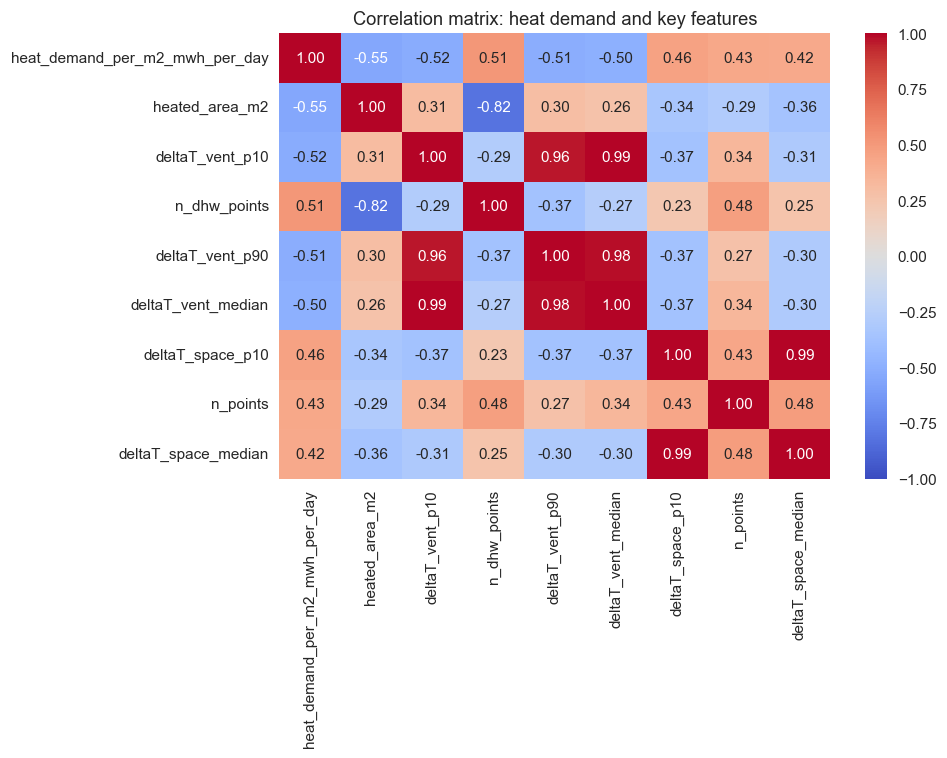


Correlation with heat demand per m² (buildings with area only):


,corr_with_heat_per_m2
heated_area_m2,-0.549411
deltaT_vent_p10,-0.520693
n_dhw_points,0.509290
deltaT_vent_p90,-0.508855
deltaT_vent_median,-0.495682
deltaT_space_p10,0.456159
n_points,0.426223
deltaT_space_median,0.419283
share_low_deltaT_vent,0.398132
deltaT_space_p90,0.345258



Sample building-day feature table (heat vs. weather):


,date,heat_mwh,building_abv,heat_target_source,heat_target_kind,temp_mean_c
0,2022-05-23,0.032,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,11.458872
1,2022-05-24,0.079,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,14.521922
2,2022-05-25,0.070,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,15.618327
3,2022-05-26,0.105,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,11.488047
4,2022-05-27,0.169,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,10.106944
5,2022-05-28,0.142,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,10.159383
6,2022-05-29,0.145,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,10.678599
7,2022-05-30,0.147,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,12.852448
8,2022-05-31,0.146,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,11.205902
9,2022-06-01,0.120,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,14.370819



Correlation between daily heat and mean outdoor temperature (per building):
  GEO: corr(heat_mwh, temp_mean_c) = -0.717
  ICO: corr(heat_mwh, temp_mean_c) = -0.897
  LIB: corr(heat_mwh, temp_mean_c) = -0.789
  SOC: corr(heat_mwh, temp_mean_c) = -0.752


In [ ]:
# Cell 4a — Per-building feature join (ventilation, ΔT, EHR)

from pathlib import Path
from typing import Optional

# Load EHR feature table exported earlier (if available)
EHR_FEATURES_FILE = CLEAN_DIR / "ehr_building_features.csv"
if EHR_FEATURES_FILE.exists():
    ehr_features_for_join = pd.read_csv(EHR_FEATURES_FILE)
else:
    ehr_features_for_join = ehr_features.copy() if "ehr_features" in globals() else None

if ehr_features_for_join is None:
    print("No EHR feature table available — run Cell 3 first.")
else:
    # Base: one row per campus building from the overview summary
    if "summary_by_building" not in globals():
        print("summary_by_building not found — run the campus overview cell (Cell 1) first.")
    else:
        base = summary_by_building.drop_duplicates("building_abv").copy()

        # Attach the updated weather-based ΔT summary when available.
        deltaT_for_join = None
        deltaT_source_name = None
        if "deltaT_summary_v2" in globals():
            deltaT_for_join = deltaT_summary_v2.copy()
            deltaT_source_name = "deltaT_summary_v2"
        elif "deltaT_summary" in globals():
            deltaT_for_join = deltaT_summary.copy()
            deltaT_source_name = "deltaT_summary"

        if deltaT_for_join is not None:
            deltaT_for_join = deltaT_for_join.drop_duplicates("building_abv")
            base = base.merge(deltaT_for_join, on="building_abv", how="left", suffixes=("", "_deltaT"))
            print(f"Using `{deltaT_source_name}` as the ΔT feature source for downstream joins.")

        # Attach EHR features: match by campus_code containing building_abv
        ehr_for_merge = ehr_features_for_join.copy()
        ehr_for_merge["campus_code"] = ehr_for_merge["campus_code"].astype(str)

        def best_ehr_match(b: str) -> Optional[str]:
            candidates = ehr_for_merge.loc[
                ehr_for_merge["campus_code"].str.contains(b, na=False),
                "campus_code",
            ].unique()
            if len(candidates) == 0:
                return None
            # Prefer exact match if present
            if b in candidates:
                return b
            return candidates[0]

        base["ehr_campus_code"] = base["building_abv"].apply(best_ehr_match)
        joined = base.merge(
            ehr_for_merge,
            left_on="ehr_campus_code",
            right_on="campus_code",
            how="left",
            suffixes=("", "_ehr"),
        )
        joined = joined.drop_duplicates("building_abv").reset_index(drop=True)

        print("Per-building joined feature table (overview):")
        cols_to_show = [c for c in [
            "building_abv", "Hoone", "vent_class", "n_vent_points",
            "deltaT_space_median", "share_low_deltaT_space",
            "heated_area_m2", "building_age_years", "energy_class",
            "ventilation_type", "usage_non_res_share_of_heated",
        ] if c in joined.columns]
        display(joined[cols_to_show].sort_values("building_abv"))

        joined_building_features = joined
        print("\nJoined building-level feature table shape:", joined_building_features.shape)

# Cell 4b — Building-level heat demand and correlation of features with heat demand

# Goal: see how metadata/features relate to actual heat demand (the outcome we care about),
# not just to each other. Compute a single heat-demand metric per building from clean hourly data.

if "joined_building_features" not in globals():
    print("joined_building_features not defined — run Cell 4a first.")
else:
    # Compute building-level heat demand from clean hourly CSVs (mean daily MWh over the period)
    heat_demand_rows = []
    for b in joined_building_features["building_abv"].dropna().unique():
        path = CLEAN_DIR / f"{b}_hourly_clean.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        if df.empty:
            continue
        try:
            target_series, target_source, target_kind = select_building_heat_target(df, building_abv=b)
        except ValueError:
            continue

        daily = target_series.resample("D").sum()
        heat_demand_mean = daily.mean()  # mean daily MWh
        heat_demand_total = daily.sum()  # total MWh over period (for reference)
        heat_demand_rows.append({
            "building_abv": b,
            "heat_target_source": target_source,
            "heat_target_kind": target_kind,
            "heat_demand_mean_daily_mwh": heat_demand_mean,
            "heat_demand_total_mwh": heat_demand_total,
        })

    if not heat_demand_rows:
        print("No clean hourly heat data found — cannot compute heat demand.")
    else:
        heat_demand_df = pd.DataFrame(heat_demand_rows)
        jbf = joined_building_features.merge(
            heat_demand_df,
            on="building_abv",
            how="left",
        )
        # Optional: normalized demand (per m²) where area is available
        if "heated_area_m2" in jbf.columns:
            jbf["heat_demand_per_m2_mwh_per_day"] = (
                jbf["heat_demand_mean_daily_mwh"] / jbf["heated_area_m2"].replace(0, np.nan)
            )
        joined_building_features = jbf

        # Prefer normalized heat demand (per m²) for cross-building comparability,
        # but keep raw mean daily MWh as a fallback target.
        target_raw = "heat_demand_mean_daily_mwh"
        target_norm = "heat_demand_per_m2_mwh_per_day"
        target = target_norm if target_norm in joined_building_features.columns and joined_building_features[target_norm].notna().sum() >= 3 else target_raw
        if target not in joined_building_features.columns:
            print("Heat-demand target not in table — check 4a/4b.")
        else:
            # Numeric features only; drop ID-like and the target itself from predictors
            numeric_cols = joined_building_features.select_dtypes(include=["number"]).columns.tolist()
            exclude = [
                "heat_demand_total_mwh",
                "heat_demand_mean_daily_mwh",
                "heat_demand_per_m2_mwh_per_day",
                "ehr_code",
            ]
            numeric_cols = [c for c in numeric_cols if c not in exclude and joined_building_features[c].notna().sum() >= 3]

            corr_with_heat = joined_building_features[numeric_cols + [target]].corr()[target].drop(target, errors="ignore")
            corr_with_heat = corr_with_heat.reindex(corr_with_heat.abs().sort_values(ascending=False).index)

            print(f"Correlation of building-level features with heat demand target: {target}")
            display(corr_with_heat.to_frame("corr_with_heat_demand"))

            # Correlation matrix (heat demand target + top features)
            top_features = corr_with_heat.index[:8].tolist()
            matrix_cols = [target] + top_features
            corr_matrix = joined_building_features[matrix_cols].corr()

            # Small textual helper: show top 5 positive/negative correlations with the target
            pos_corr = corr_with_heat[corr_with_heat > 0].sort_values(ascending=False).head(5)
            neg_corr = corr_with_heat[corr_with_heat < 0].sort_values().head(5)
            print("\nTop 5 features positively correlated with heat demand target:")
            display(pos_corr.to_frame("corr_with_target"))
            print("\nTop 5 features negatively correlated with heat demand target:")
            display(neg_corr.to_frame("corr_with_target"))

            plt.figure(figsize=(9, 7))
            sns.heatmap(
                corr_matrix,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                vmin=-1,
                vmax=1,
            )
            plt.title("Correlation matrix: heat demand and key features")
            plt.tight_layout()
            plt.show()

            # If we have normalized demand, also show correlations with that
            if target_norm in joined_building_features.columns:
                valid = joined_building_features[target_norm].notna()
                if valid.sum() >= 3:
                    corr_norm = joined_building_features.loc[valid, numeric_cols + [target_norm]].corr()[target_norm].drop(target_norm, errors="ignore")
                    corr_norm = corr_norm.reindex(corr_norm.abs().sort_values(ascending=False).index)
                    print("\nCorrelation with heat demand per m² (buildings with area only):")
                    display(corr_norm.to_frame("corr_with_heat_per_m2").head(12))

# Cell 4c — Prototype building-day feature table (heat vs. weather)

from datetime import datetime

WEATHER_FILE = WEATHER_FILE  # already defined in Cell 0

if not WEATHER_FILE.exists():
    print("Weather file not found — skipping building-day prototype.")
else:
    # The combined weather file uses a `datetime` column and multiple station variables.
    weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"])
    weather["date"] = weather["datetime"].dt.date

    # Simple daily mean outdoor temperature proxy (use one station, e.g. COP_temp_c)
    temp_col = "COP_temp_c" if "COP_temp_c" in weather.columns else weather.columns[1]
    daily_temp = (
        weather
        .groupby("date", as_index=False)[temp_col]
        .mean()
        .rename(columns={temp_col: "temp_mean_c"})
    )

    # Prototype for one or a few buildings to keep it light
    sample_buildings = [
        b for b in joined_building_features["building_abv"].dropna().unique()
        if (CLEAN_DIR / f"{b}_hourly_clean.csv").exists()
    ][:4]

    building_daily_frames = []
    for b in sample_buildings:
        path = CLEAN_DIR / f"{b}_hourly_clean.csv"
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        if df.empty:
            continue

        try:
            target_series, target_source, target_kind = select_building_heat_target(df, building_abv=b)
        except ValueError:
            continue

        tmp = target_series.to_frame("heat_mwh")
        tmp["date"] = tmp.index.date
        daily = (
            tmp
            .groupby("date", as_index=False)["heat_mwh"]
            .sum()
        )
        daily["building_abv"] = b
        daily["heat_target_source"] = target_source
        daily["heat_target_kind"] = target_kind
        building_daily_frames.append(daily)

    if not building_daily_frames:
        print("No suitable clean hourly datasets found for building-day prototype.")
    else:
        daily_heat = pd.concat(building_daily_frames, ignore_index=True)
        building_day = daily_heat.merge(daily_temp, on="date", how="left")

        print("\nSample building-day feature table (heat vs. weather):")
        display(building_day.head(20))

        # Simple correlation between daily heat and temperature per building
        print("\nCorrelation between daily heat and mean outdoor temperature (per building):")
        for b, grp in building_day.groupby("building_abv"):
            if grp["temp_mean_c"].notna().sum() < 5:
                continue
            corr_ht = grp[["heat_mwh", "temp_mean_c"]].corr().iloc[0, 1]
            print(f"  {b}: corr(heat_mwh, temp_mean_c) = {corr_ht:.3f}")


## Cell 5 — Heat vs weather and ventilation richness (exploratory)

Now that we have building-level features and a prototype building-day table, this section explores **how daily heat demand (per m²)** relates to **outdoor temperature** and **ventilation richness (`vent_class`)**.

Questions we look at:

- How does **daily heat per m²** vary with temperature for different buildings?
- Do buildings with richer ventilation metering (`vent_class = rich`) show different **slopes** of heat-vs-temperature than `basic` / `none`?
- Are there obvious outliers or groups that merit deeper inertia-focused analysis later?

Daily heat per m² vs temperature (first rows):


,date,heat_mwh,building_abv,heat_target_source,heat_target_kind,temp_mean_c,vent_class,heated_area_m2,heat_mwh_per_m2
0,2022-01-01,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-4.601329,basic,898.2,0.0
1,2022-01-02,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-5.836395,basic,898.2,0.0
2,2022-01-03,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-0.813792,basic,898.2,0.0
3,2022-01-04,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,0.714427,basic,898.2,0.0
4,2022-01-05,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-1.866323,basic,898.2,0.0
5,2022-01-06,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-4.285400,basic,898.2,0.0
6,2022-01-07,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-6.652852,basic,898.2,0.0
7,2022-01-08,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-7.482361,basic,898.2,0.0
8,2022-01-09,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-2.440816,basic,898.2,0.0
9,2022-01-10,0.0,GEO,bldg_space_heat_BHB02_mwh + bldg_vent_heat_BHB...,sum_comfort_heat,-6.282440,basic,898.2,0.0


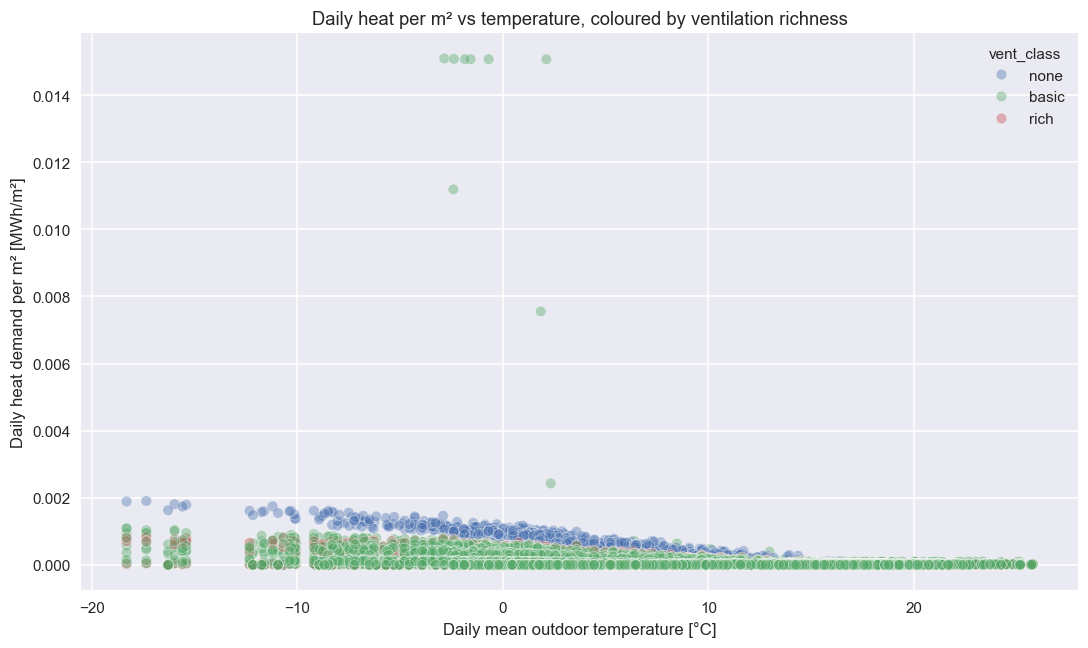


Per-building slopes of heat_per_m2 vs temperature:


,building_abv,vent_class,heat_target_kind,slope_heat_per_m2_per_deg,intercept,n_days
3,U01,none,sum_comfort_heat,-4.129798e-05,0.000715,1096
0,GEO,basic,sum_comfort_heat,-2.379949e-05,0.000428,1096
2,SOC,basic,sum_comfort_heat,-1.900789e-05,0.000337,1096
6,U03,rich,total_heat,-1.834981e-05,0.000317,1096
9,U05,basic,total_heat,-1.729956e-05,0.000300,1096
8,U04,rich,total_heat,-1.368140e-05,0.000237,1096
10,U06,basic,total_heat,-1.316339e-05,0.000229,1096
1,LIB,basic,sum_comfort_heat,-1.006182e-05,0.000177,1096
7,U03B,basic,total_heat,-6.426158e-06,0.000113,1096
11,U06A,basic,total_heat,-3.145374e-06,0.000056,1096



Median slopes of heat_per_m2 vs temperature by vent_class:


,median_slope
vent_class,
none,-0.000041
rich,-0.000014
basic,-0.000012


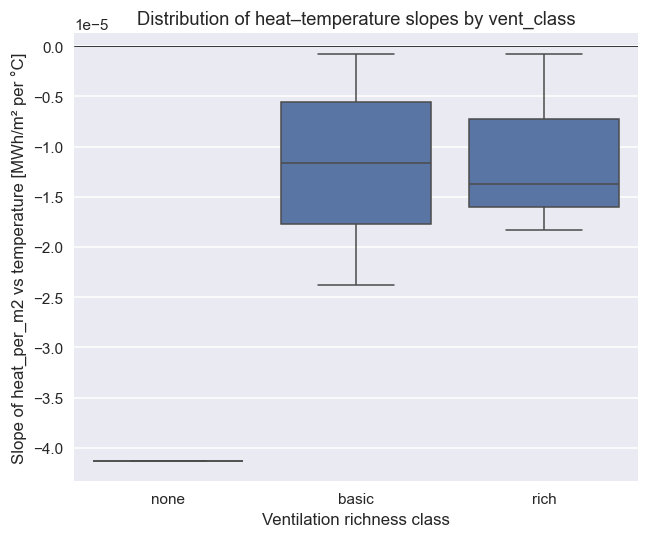

In [58]:
# Cell 5a — Daily heat per m² vs temperature, by ventilation richness

from typing import List

if "joined_building_features" not in globals():
    print("joined_building_features not defined — run Cells 4a/4b first.")
elif "summary_by_building" not in globals():
    print("summary_by_building not found — run the campus overview cell (Cell 1) first.")
else:
    # Reuse or (re)build a daily heat table, now for all buildings that have clean hourly data
    if "building_day_full" in globals():
        building_day = building_day_full.copy()
    else:
        if not WEATHER_FILE.exists():
            print("Weather file not found — skipping heat vs weather exploration.")
        else:
            weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"])
            weather["date"] = weather["datetime"].dt.date
            temp_col = "COP_temp_c" if "COP_temp_c" in weather.columns else weather.columns[1]
            daily_temp = (
                weather
                .groupby("date", as_index=False)[temp_col]
                .mean()
                .rename(columns={temp_col: "temp_mean_c"})
            )

            buildings_with_clean: List[str] = [
                b for b in joined_building_features["building_abv"].dropna().unique()
                if (CLEAN_DIR / f"{b}_hourly_clean.csv").exists()
            ]

            frames = []
            for b in buildings_with_clean:
                path = CLEAN_DIR / f"{b}_hourly_clean.csv"
                df = pd.read_csv(path, index_col=0, parse_dates=True)
                if df.empty:
                    continue
                try:
                    target_series, target_source, target_kind = select_building_heat_target(df, building_abv=b)
                except ValueError:
                    continue
                tmp = target_series.to_frame("heat_mwh")
                tmp["date"] = tmp.index.date
                daily = (
                    tmp
                    .groupby("date", as_index=False)["heat_mwh"]
                    .sum()
                )
                daily["building_abv"] = b
                daily["heat_target_source"] = target_source
                daily["heat_target_kind"] = target_kind
                frames.append(daily)

            if not frames:
                print("No suitable clean hourly datasets found for heat vs weather exploration.")
                building_day = None
            else:
                daily_heat = pd.concat(frames, ignore_index=True)
                building_day = daily_heat.merge(daily_temp, on="date", how="left")
                building_day_full = building_day.copy()

    if building_day is not None:
        # Attach area and vent_class for normalization and grouping
        meta = summary_by_building[["building_abv", "vent_class"]].drop_duplicates("building_abv").merge(
            joined_building_features[["building_abv", "heated_area_m2"]].drop_duplicates("building_abv"),
            on="building_abv",
            how="left",
        )
        bd = building_day.merge(meta, on="building_abv", how="left")

        if "heated_area_m2" in bd.columns:
            bd["heat_mwh_per_m2"] = bd["heat_mwh"] / bd["heated_area_m2"].replace(0, np.nan)
        else:
            bd["heat_mwh_per_m2"] = np.nan

        print("Daily heat per m² vs temperature (first rows):")
        display(bd.head(20))

        # Scatter: all buildings, colour by vent_class
        subset = bd.dropna(subset=["heat_mwh_per_m2", "temp_mean_c", "vent_class"])
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=subset,
            x="temp_mean_c",
            y="heat_mwh_per_m2",
            hue="vent_class",
            alpha=0.4,
        )
        plt.xlabel("Daily mean outdoor temperature [°C]")
        plt.ylabel("Daily heat demand per m² [MWh/m²]")
        plt.title("Daily heat per m² vs temperature, coloured by ventilation richness")
        plt.legend(title="vent_class")
        plt.tight_layout()
        plt.show()

        # Per-building linear slopes (heat_per_m2 vs temp) and comparison by vent_class
        rows = []
        for (b, vc), grp in subset.groupby(["building_abv", "vent_class"], observed=False):
            g = grp.dropna(subset=["heat_mwh_per_m2", "temp_mean_c"])
            if len(g) < 10:
                continue
            x = g["temp_mean_c"].values
            y = g["heat_mwh_per_m2"].values
            # Fit simple linear model y = a*x + b
            a, b0 = np.polyfit(x, y, 1)
            rows.append({
                "building_abv": b,
                "vent_class": vc,
                "heat_target_kind": g["heat_target_kind"].iloc[0] if "heat_target_kind" in g.columns else np.nan,
                "slope_heat_per_m2_per_deg": a,
                "intercept": b0,
                "n_days": len(g),
            })

        if not rows:
            print("Not enough daily points per building for slope analysis.")
        else:
            slope_df = pd.DataFrame(rows)
            print("\nPer-building slopes of heat_per_m2 vs temperature:")
            display(slope_df.sort_values("slope_heat_per_m2_per_deg"))

            # Group-level summary by vent_class to help interpretation
            if "vent_class" in slope_df.columns:
                print("\nMedian slopes of heat_per_m2 vs temperature by vent_class:")
                med_slopes = slope_df.groupby("vent_class", observed=False)["slope_heat_per_m2_per_deg"].median().sort_values()
                display(med_slopes.to_frame("median_slope"))

            plt.figure(figsize=(6, 5))
            sns.boxplot(
                data=slope_df,
                x="vent_class",
                y="slope_heat_per_m2_per_deg",
                order=["none", "basic", "rich"],
            )
            plt.axhline(0, color="black", linewidth=0.5)
            plt.xlabel("Ventilation richness class")
            plt.ylabel("Slope of heat_per_m2 vs temperature [MWh/m² per °C]")
            plt.title("Distribution of heat–temperature slopes by vent_class")
            plt.tight_layout()
            plt.show()


## Cell 6 — Inertia-aware dynamic features (exploratory)

This section prototypes simple **inertia/dynamics metrics** from the hourly heat data and relates them to the building metadata we have so far.

Focus:

- Hourly **autocorrelation** of heat demand (lags 1–24 h) as a crude inertia signal.
- **Night-setback metric**: ratio of night-time to daytime heat per m² in the heating season.
- Compare these metrics across buildings and by `vent_class` and other features to see which buildings look more/less inertia-dominated.

These are *exploratory* metrics meant to shape intuition and guide which buildings to analyze more deeply later, not final model features.

Inertia/dynamic metrics per building:


,building_abv,heat_target_source,heat_target_kind,ac1,ac24,night_mean_heat_per_m2,day_mean_heat_per_m2,night_day_ratio,vent_class,n_vent_points,heated_area_m2,energy_class
7,U02,U02__weather_driven__energy_delta_mwh,merged_weather_driven,0.861724,0.643057,3.253211e-07,0.000001,0.228212,rich,3,24136.0,NaN
3,SOC,SOC__weather_driven__energy_delta_mwh,merged_weather_driven,0.574985,0.485927,1.346467e-05,0.000026,0.522618,basic,2,10360.0,NaN
8,U02B,U02B__weather_driven__energy_delta_mwh,merged_weather_driven,0.657736,0.644940,6.017198e-07,0.000001,0.549933,basic,1,24136.0,NaN
0,GEO,GEO__weather_driven__energy_delta_mwh,merged_weather_driven,0.933070,0.710894,1.018718e-05,0.000017,0.584700,basic,1,898.2,NaN
13,U05,U05__weather_driven__energy_delta_mwh,merged_weather_driven,0.728518,0.690415,1.188136e-05,0.000019,0.617253,basic,2,5550.0,E
16,U06A,U06A__weather_driven__energy_delta_mwh,merged_weather_driven,0.644689,0.616299,1.562463e-06,0.000002,0.694226,basic,1,12841.2,D
10,U03B,U03B__weather_driven__energy_delta_mwh,merged_weather_driven,0.655238,0.538258,5.768589e-06,0.000008,0.763897,basic,1,5908.0,NaN
2,LIB,LIB__weather_driven__energy_delta_mwh,merged_weather_driven,0.421793,0.396679,9.789546e-06,0.000012,0.790830,basic,1,10647.0,NaN
9,U03,U03__weather_driven__energy_delta_mwh,merged_weather_driven,0.522556,0.545596,1.602496e-05,0.000020,0.792588,rich,4,5908.0,NaN
15,U06,U06__weather_driven__energy_delta_mwh,merged_weather_driven,0.556981,0.537659,8.199221e-06,0.000010,0.829205,basic,1,12841.2,D



Median night_day_ratio and ac24 by vent_class:


,night_day_ratio,ac24
vent_class,,
none,0.976499,0.460520
basic,0.655740,0.616299
rich,0.792588,0.643057


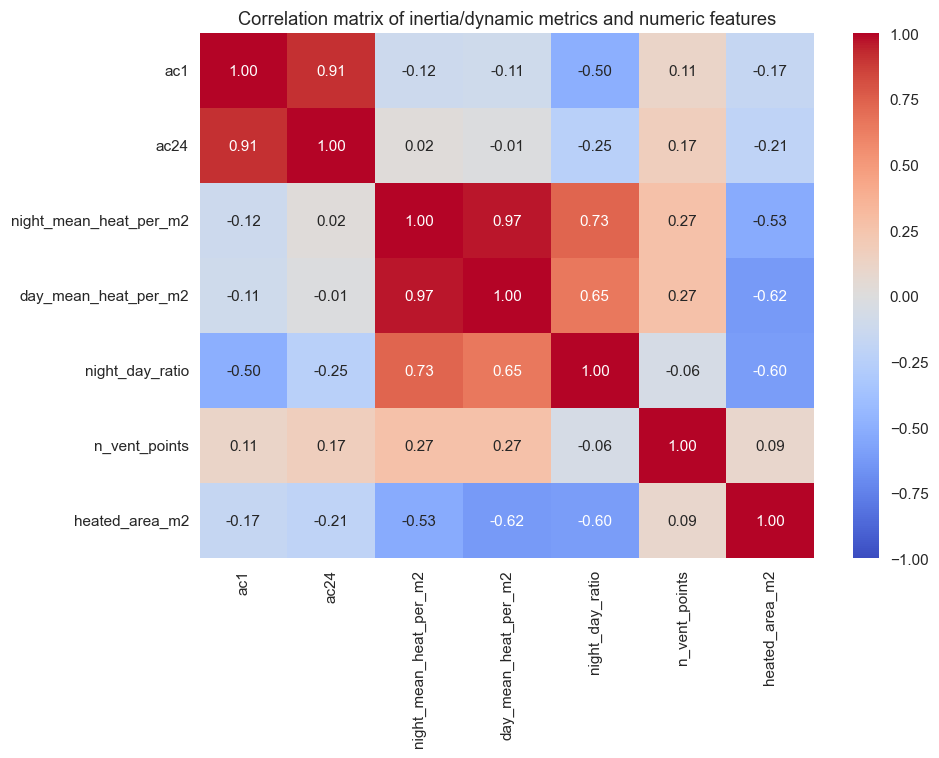

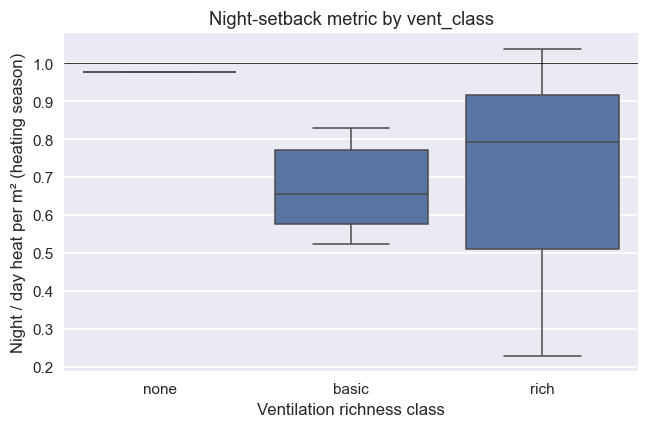

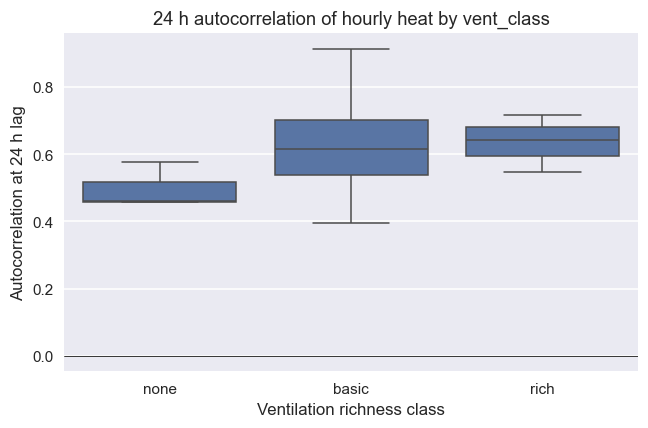

In [ ]:
# Cell 6a — Autocorrelation and night-setback metrics per building

from typing import List, Dict, Any

if "joined_building_features" not in globals():
    print("joined_building_features not defined — run Cells 4a/4b first.")
else:
    buildings_with_clean: List[str] = [
        b for b in joined_building_features["building_abv"].dropna().unique()
        if (CLEAN_DIR / f"{b}_hourly_clean.csv").exists()
    ]

    metrics_rows: List[Dict[str, Any]] = []
    area_lookup = joined_building_features[["building_abv", "heated_area_m2"]].drop_duplicates("building_abv")

    for b in buildings_with_clean:
        path = CLEAN_DIR / f"{b}_hourly_clean.csv"
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        if df.empty:
            continue

        try:
            s, target_source, target_kind = select_building_heat_target(df, building_abv=b)
        except ValueError:
            continue

        # Restrict to heating season months (Nov–Mar) to focus on real heating behaviour
        heating = s[(s.index.month >= 11) | (s.index.month <= 3)]
        if heating.empty:
            continue

        # Simple hourly autocorrelations at lag 1 and 24
        def safe_autocorr(series: pd.Series, lag: int) -> float:
            if len(series.dropna()) <= lag + 1:
                return np.nan
            return series.autocorr(lag)

        ac1 = safe_autocorr(heating, 1)
        ac24 = safe_autocorr(heating, 24)

        # Night-setback metric: night vs day heat per m²
        # Define local time-of-day based on index hour
        h = heating.copy()
        h_df = h.to_frame("heat_mwh")
        h_df["hour"] = h_df.index.hour
        h_df["date"] = h_df.index.date

        # Attach heated area for this building (if known)
        area = area_lookup.loc[
            area_lookup["building_abv"] == b,
            "heated_area_m2",
        ]
        area_val = float(area.iloc[0]) if not area.empty else np.nan

        if not np.isnan(area_val) and area_val > 0:
            h_df["heat_mwh_per_m2"] = h_df["heat_mwh"] / area_val
        else:
            h_df["heat_mwh_per_m2"] = np.nan

        # Night: 00–05, Day: 08–18
        night = h_df[(h_df["hour"] >= 0) & (h_df["hour"] <= 5)]
        day = h_df[(h_df["hour"] >= 8) & (h_df["hour"] <= 18)]

        night_mean = night["heat_mwh_per_m2"].mean()
        day_mean = day["heat_mwh_per_m2"].mean()
        night_day_ratio = night_mean / day_mean if pd.notna(day_mean) and day_mean != 0 else np.nan

        metrics_rows.append({
            "building_abv": b,
            "heat_target_source": target_source,
            "heat_target_kind": target_kind,
            "ac1": ac1,
            "ac24": ac24,
            "night_mean_heat_per_m2": night_mean,
            "day_mean_heat_per_m2": day_mean,
            "night_day_ratio": night_day_ratio,
        })

    if not metrics_rows:
        print("No inertia/dynamic metrics could be computed — check clean hourly datasets.")
    else:
        inertia_df = pd.DataFrame(metrics_rows)

        # Attach metadata: vent_class, heated_area, energy_class etc.
        meta_cols = [
            "building_abv",
            "vent_class",
            "n_vent_points",
            "heated_area_m2",
            "energy_class",
        ]
        meta_for_inertia = joined_building_features[[c for c in meta_cols if c in joined_building_features.columns]].drop_duplicates("building_abv")

        inertia_df = inertia_df.merge(meta_for_inertia, on="building_abv", how="left")

        print("Inertia/dynamic metrics per building:")
        display(inertia_df.sort_values("night_day_ratio"))

        # Simple group summaries by vent_class to support interpretation
        if "vent_class" in inertia_df.columns:
            print("\nMedian night_day_ratio and ac24 by vent_class:")
            group_med = inertia_df.groupby("vent_class", observed=False)[["night_day_ratio", "ac24"]].median().sort_index()
            display(group_med)

        # Quick correlation view: how do inertia metrics relate to other building features?
        numeric_cols = inertia_df.select_dtypes(include=["number"]).columns.tolist()
        corr_inertia = inertia_df[numeric_cols].corr()

        plt.figure(figsize=(9, 7))
        sns.heatmap(
            corr_inertia,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
        )
        plt.title("Correlation matrix of inertia/dynamic metrics and numeric features")
        plt.tight_layout()
        plt.show()

        # Boxplots by vent_class for night_day_ratio and ac24
        if "vent_class" in inertia_df.columns:
            plt.figure(figsize=(6, 4))
            sns.boxplot(
                data=inertia_df,
                x="vent_class",
                y="night_day_ratio",
                order=["none", "basic", "rich"],
            )
            plt.axhline(1.0, color="black", linewidth=0.5)
            plt.ylabel("Night / day heat per m² (heating season)")
            plt.xlabel("Ventilation richness class")
            plt.title("Night-setback metric by vent_class")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(6, 4))
            sns.boxplot(
                data=inertia_df,
                x="vent_class",
                y="ac24",
                order=["none", "basic", "rich"],
            )
            plt.axhline(0.0, color="black", linewidth=0.5)
            plt.ylabel("Autocorrelation at 24 h lag")
            plt.xlabel("Ventilation richness class")
            plt.title("24 h autocorrelation of hourly heat by vent_class")
            plt.tight_layout()
            plt.show()


## Cell 7 — Summary of exploratory findings and modelling implications

This section summarises **what we learned** from the campus EHR, ventilation, ΔT, and dynamic analyses, and how it should guide later modelling notebooks.

High-level points to capture here (you can lean on the printed summaries from Cells 4–6):

- Which buildings have **usable EHR area/energy class** data (and which do not), and how that constrains energy-class-based normalisation.
- From Cell 4b: which features show the **strongest positive/negative correlation with heat demand (per m²)**, using the printed top-5 lists and the correlation matrix.
- From Cell 5a: how **heat-per-m² vs temperature slopes** differ across `vent_class` (using the median slopes by class), and whether any buildings look like clear outliers.
- From Cell 6a: how **night-setback (night_day_ratio)** and **24 h autocorrelation (ac24)** vary by `vent_class` (using the group medians), and what that suggests about inertia/control differences between buildings.
- Concrete takeaways about **which buildings** are most promising for inertia-aware modelling and where instrumentation/metadata gaps limit interpretability.

Use this cell mainly for **narrative text** and 1–2 key screenshots/figures (kept small) that you may want to reference directly in the thesis document.

In [60]:
# Cell 7a — Export modelling-ready feature tables

"""Create tidy CSVs for later modelling notebooks.

Outputs in `data/clean/`:
- `campus_building_features_for_models.csv`: one row per building with metadata,
  EHR features, ΔT stats, and simple inertia metrics (where available).
- `campus_building_day_features.csv`: building–day level table with daily heat,
  temperature, and heat per m² (for buildings where area is known).
"""

# 1) Building-level features
if "joined_building_features" not in globals():
    print("joined_building_features not defined — run Cells 4a/4b first.")
else:
    bldg_feats = joined_building_features.drop_duplicates("building_abv").copy()

    # Attach inertia metrics if available
    if "inertia_df" in globals():
        inertia_min = inertia_df[[
            "building_abv",
            "ac1",
            "ac24",
            "night_mean_heat_per_m2",
            "day_mean_heat_per_m2",
            "night_day_ratio",
        ]].copy()
        bldg_feats = bldg_feats.merge(inertia_min, on="building_abv", how="left")

    bldg_out_path = CLEAN_DIR / "campus_building_features_for_models.csv"
    bldg_feats.to_csv(bldg_out_path, index=False)
    print("Saved building-level feature table to:", bldg_out_path)

# 2) Building–day features

# Prefer the full building-day table if we built it in Cell 5a
if "building_day_full" in globals():
    bd = building_day_full.copy()
elif "building_day" in globals():
    bd = building_day.copy()
else:
    bd = None

if bd is None:
    print("No building-day table in memory — skip export for now.")
else:
    # Attach area to allow per-m² normalisation
    if "heated_area_m2" not in bd.columns and "joined_building_features" in globals():
        area_meta = joined_building_features[["building_abv", "heated_area_m2"]].drop_duplicates("building_abv")
        bd = bd.merge(area_meta, on="building_abv", how="left")

    if "heat_mwh_per_m2" not in bd.columns:
        if "heated_area_m2" in bd.columns:
            bd["heat_mwh_per_m2"] = bd["heat_mwh"] / bd["heated_area_m2"].replace(0, np.nan)

    day_out_path = CLEAN_DIR / "campus_building_day_features.csv"
    bd.to_csv(day_out_path, index=False)
    print("Saved building–day feature table to:", day_out_path)


Saved building-level feature table to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean/campus_building_features_for_models.csv
Saved building–day feature table to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean/campus_building_day_features.csv


## Cell 8 — Train/test monthly profile diagnostics

This final section adds a very simple **train/test comparability view** for demand and weather.

It is meant to answer practical questions such as:

- How much winter-like training history does each building actually have before 2024?
- Do the **daily demand shapes** in the 2024 test months resemble those seen in the earlier training winters?
- Is the 2024 weather profile noticeably different from the training-period winters?

The section produces three quick outputs:

1. one illustrative **single-building** panel with one line per calendar month,
2. one **portfolio-wide** grid with the same demand-profile idea for every building,
3. one compact **heating-season coverage table** summarising how many train/test winter months and days each building contributes.

By default the plots focus on the core heating months `Jan`, `Feb`, `Mar`, `Nov`, and `Dec`, but this can be toggled to all months in the code cell below.


Monthly profile scope: Jan, Feb, Mar, Nov, Dec
Buildings with usable profile data: 17



,building_abv,target_kind,n_train_profile_months,n_test_profile_months,n_train_profile_days,n_test_profile_days,first_profile_day,last_profile_day
0,SOC,merged_weather_driven,7,5,192,143,2022-11-03,2024-12-31
1,LIB,merged_weather_driven,7,5,194,143,2022-11-03,2024-12-31
2,GEO,merged_weather_driven,7,5,205,144,2022-11-01,2024-12-31
3,U01,merged_weather_driven,7,5,210,152,2022-11-01,2024-12-31
4,U02,merged_weather_driven,7,5,210,136,2022-11-01,2024-12-30
5,U02B,merged_weather_driven,7,5,210,136,2022-11-01,2024-12-30
6,U03,merged_weather_driven,7,5,210,136,2022-11-01,2024-12-30
7,U03B,merged_weather_driven,7,5,210,136,2022-11-01,2024-12-30
8,U05B,merged_weather_driven,7,5,210,136,2022-11-01,2024-12-30
9,ICO,merged_weather_driven,7,5,212,143,2022-11-01,2024-12-31


Saved profile coverage table to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/monthly_train_test_profile_coverage.csv


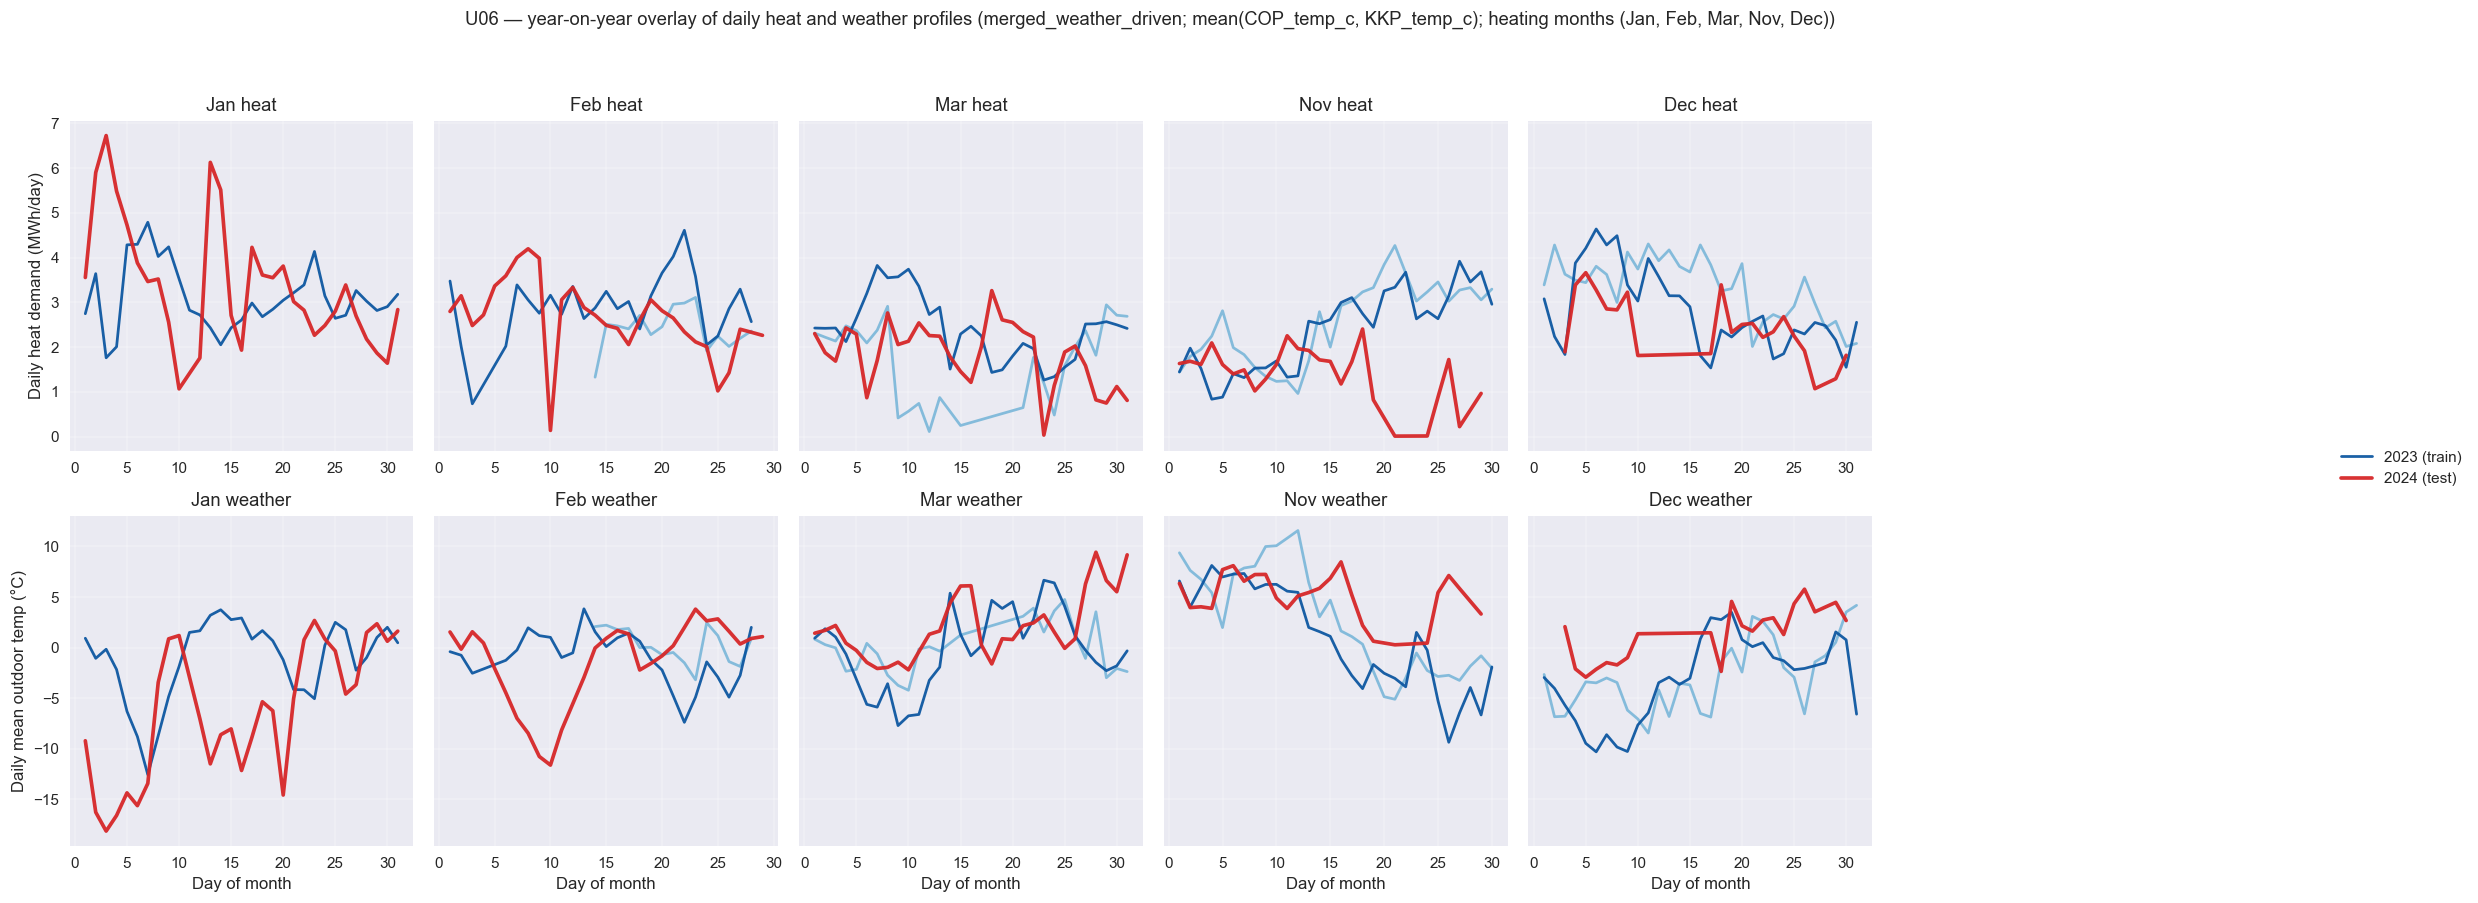

Saved single-building profile figure to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/U06_monthly_train_test_profiles_yoy.png


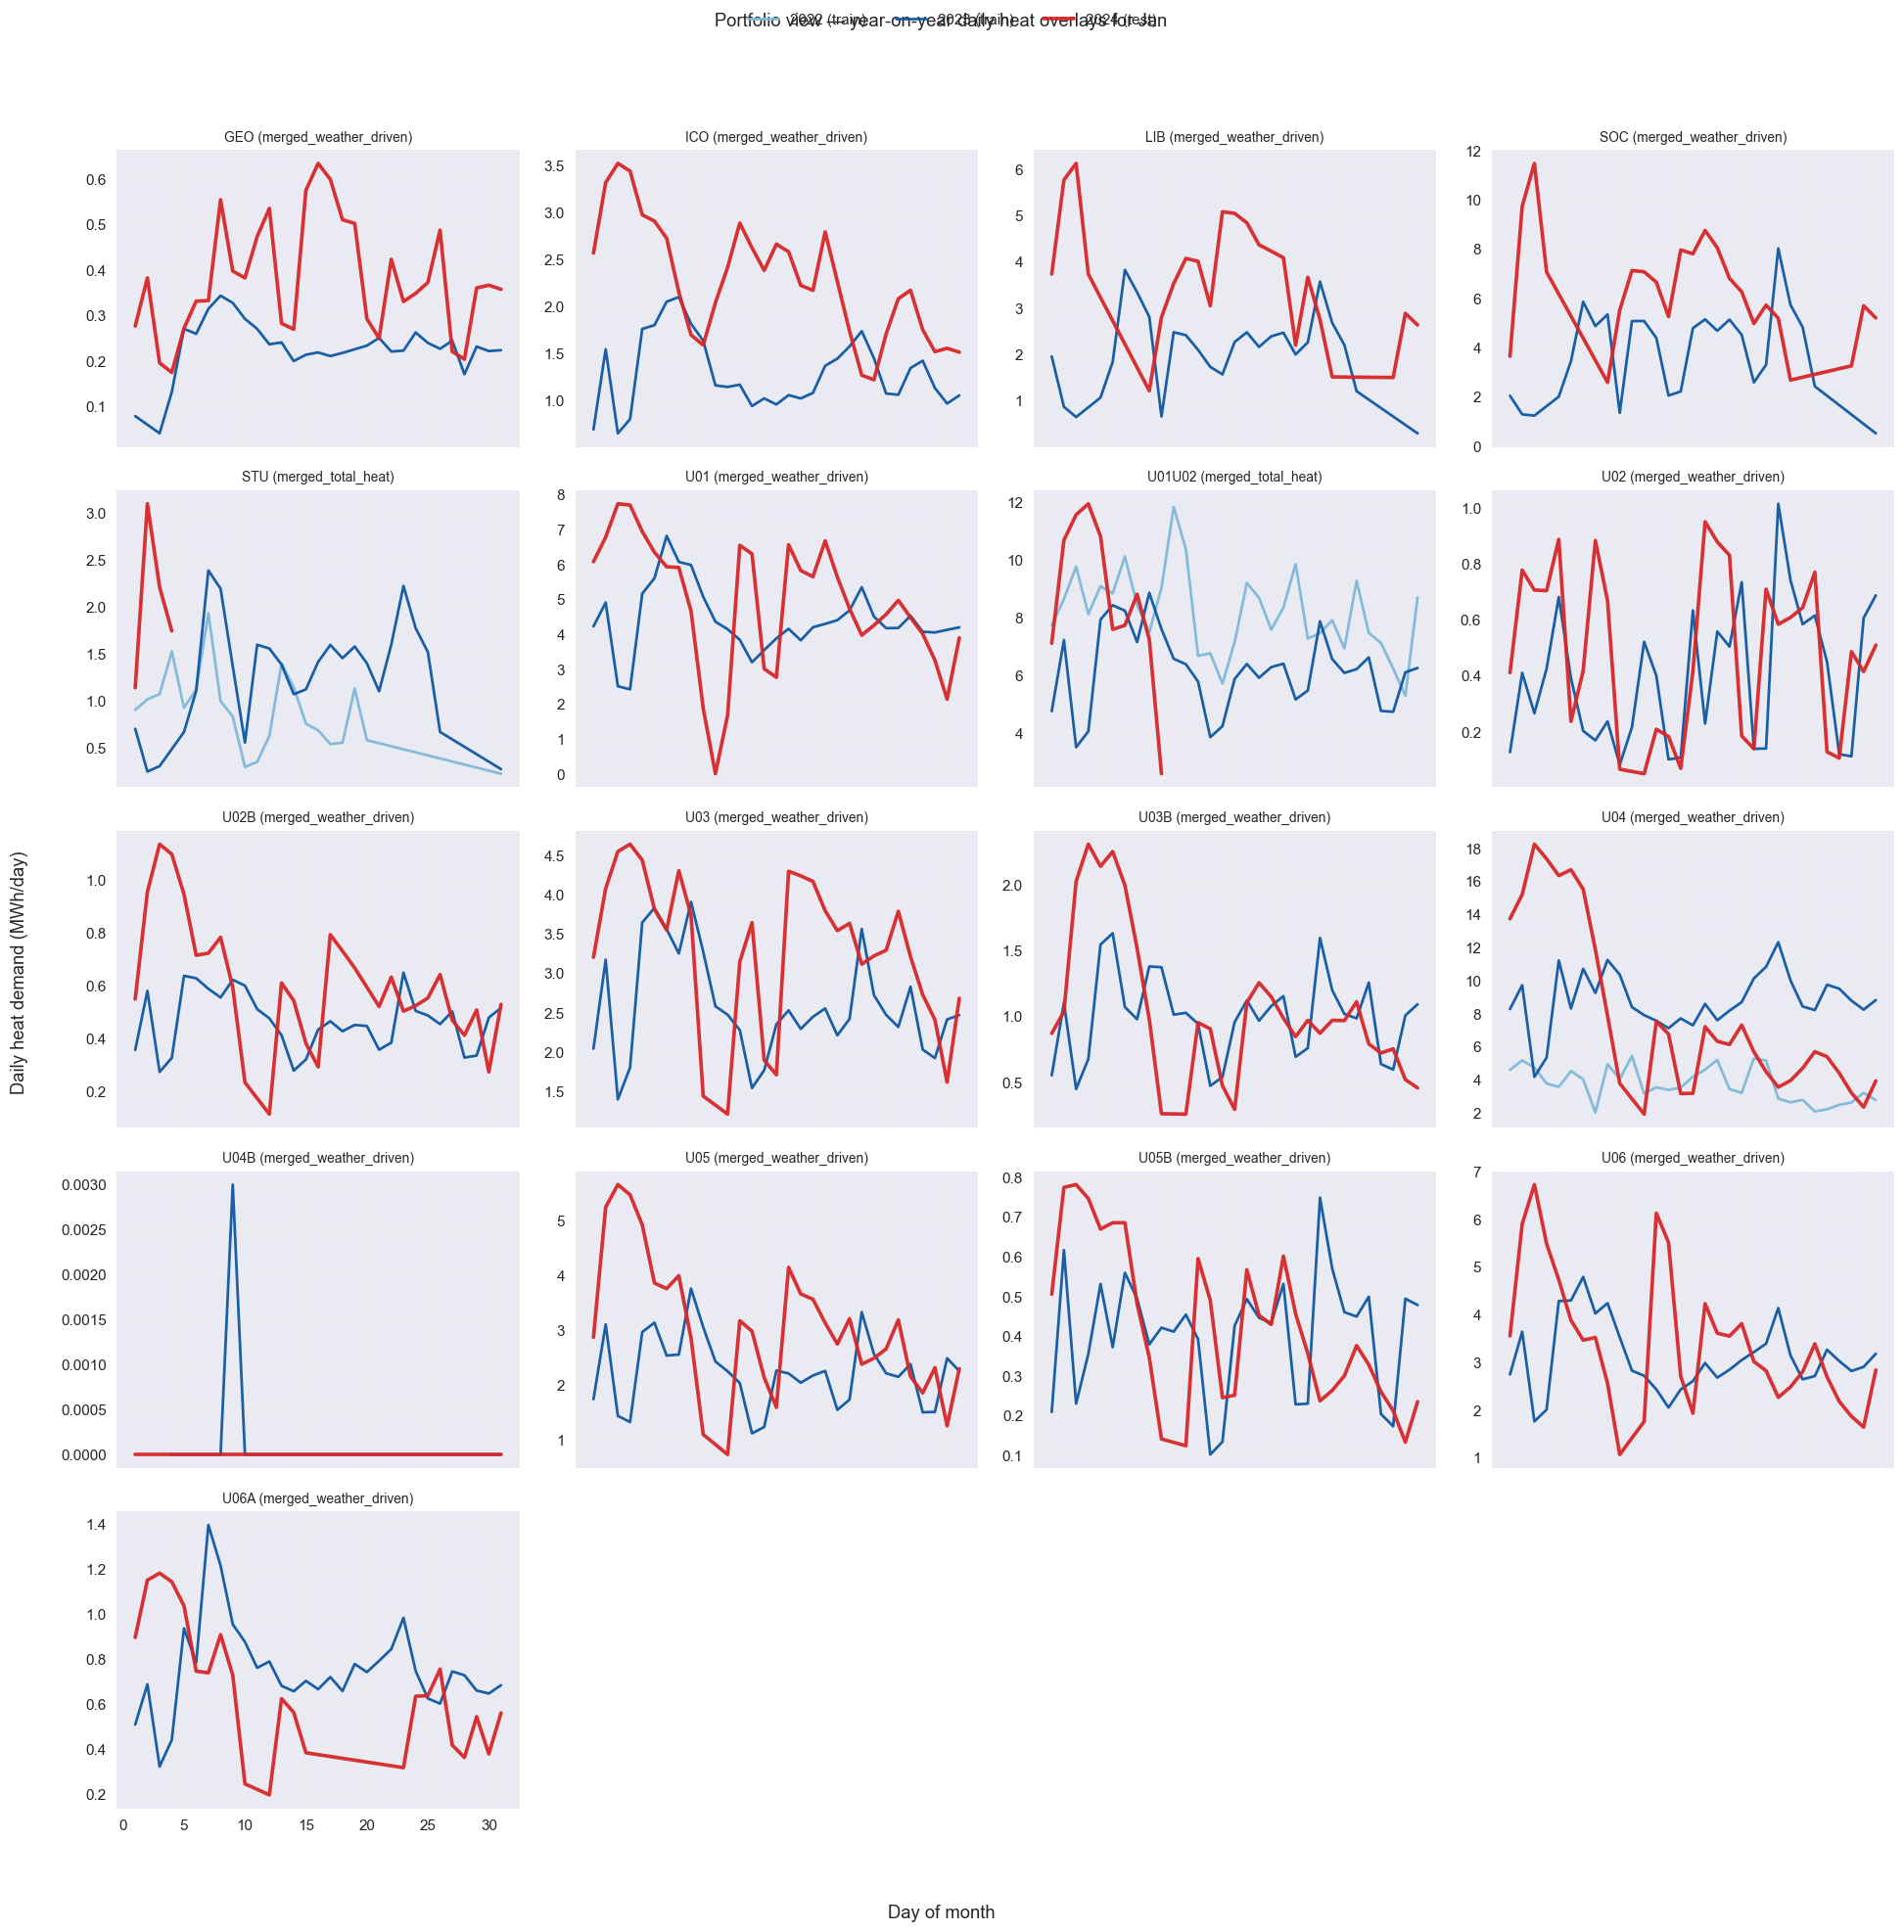

Saved portfolio profile figure to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/portfolio_monthly_train_test_profiles_yoy_jan.png


In [62]:
# Cell 8a — Train/test monthly profile diagnostics

from math import ceil
from matplotlib.lines import Line2D

PROFILE_BUILDING = "U06"          # illustrative single-building plot
PROFILE_MONTHS = [1, 2, 3, 11, 12] # focus on winter-like months by default
SHOW_ALL_MONTHS = False            # set True to compare all months instead
TRAIN_TEST_BOUNDARY = pd.Timestamp("2024-01-01")
SAVE_PROFILE_FIGURES = True
PORTFOLIO_OVERLAY_MONTH = 1      # month used for the portfolio year-on-year overlay

RESULTS_DIR = PROJECT_ROOT / "results"
if SAVE_PROFILE_FIGURES:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_daily_weather_profile() -> pd.DataFrame:
    weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"]).set_index("datetime").sort_index()

    if {"COP_temp_c", "KKP_temp_c"}.issubset(weather.columns):
        temp = weather[["COP_temp_c", "KKP_temp_c"]].mean(axis=1)
        temp_name = "mean(COP_temp_c, KKP_temp_c)"
    else:
        candidates = [
            c for c in ["wx_outdoor_temp_c", "outdoor_temp_c", "COP_temp_c", "KKP_temp_c"]
            if c in weather.columns
        ]
        if not candidates:
            candidates = list(weather.select_dtypes(include="number").columns)
        if not candidates:
            raise ValueError("No numeric weather column available for profile diagnostics.")
        temp_name = candidates[0]
        temp = weather[temp_name].astype(float)

    daily = temp.rename("temp_c").resample("D").mean().to_frame()
    daily.index.name = "date"
    daily = daily.reset_index()
    daily["year"] = daily["date"].dt.year
    daily["month"] = daily["date"].dt.month
    daily["day"] = daily["date"].dt.day
    daily["year_month"] = daily["date"].dt.strftime("%Y-%m")
    daily["split"] = np.where(daily["date"] < TRAIN_TEST_BOUNDARY, "train", "test")
    daily["temp_source"] = temp_name

    if not SHOW_ALL_MONTHS:
        daily = daily[daily["month"].isin(PROFILE_MONTHS)].copy()

    return daily


def build_daily_target_profile(building_abv: str, daily_weather: pd.DataFrame) -> pd.DataFrame | None:
    path = CLEAN_DIR / f"{building_abv}_hourly_clean.csv"
    if not path.exists():
        return None

    df = pd.read_csv(path, index_col=0, parse_dates=True)
    if df.empty:
        return None

    try:
        target_series, target_source, target_kind = select_building_heat_target(df, building_abv=building_abv)
    except ValueError:
        return None

    daily = target_series.rename("heat_mwh").resample("D").sum(min_count=1).to_frame()
    daily.index.name = "date"
    daily = daily.reset_index()
    daily = daily.dropna(subset=["heat_mwh"]).copy()

    if daily.empty:
        return None

    daily["building_abv"] = building_abv
    daily["target_source"] = target_source
    daily["target_kind"] = target_kind
    daily["year"] = daily["date"].dt.year
    daily["month"] = daily["date"].dt.month
    daily["day"] = daily["date"].dt.day
    daily["year_month"] = daily["date"].dt.strftime("%Y-%m")
    daily["split"] = np.where(daily["date"] < TRAIN_TEST_BOUNDARY, "train", "test")

    if not SHOW_ALL_MONTHS:
        daily = daily[daily["month"].isin(PROFILE_MONTHS)].copy()

    daily = daily.merge(
        daily_weather[["date", "temp_c", "temp_source"]],
        on="date",
        how="left",
    )

    return daily


def summarize_profile_coverage(profile_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for building_abv, grp in profile_df.groupby("building_abv"):
        train = grp[grp["split"] == "train"]
        test = grp[grp["split"] == "test"]
        rows.append({
            "building_abv": building_abv,
            "target_kind": grp["target_kind"].iloc[0],
            "first_profile_day": grp["date"].min(),
            "last_profile_day": grp["date"].max(),
            "n_train_profile_days": int(train["date"].nunique()),
            "n_test_profile_days": int(test["date"].nunique()),
            "n_train_profile_months": int(train["year_month"].nunique()),
            "n_test_profile_months": int(test["year_month"].nunique()),
            "train_profile_months": ", ".join(sorted(train["year_month"].unique())),
            "test_profile_months": ", ".join(sorted(test["year_month"].unique())),
        })
    return pd.DataFrame(rows).sort_values(["n_train_profile_months", "n_train_profile_days", "building_abv"], ascending=[True, True, True]).reset_index(drop=True)


def month_label(month: int) -> str:
    return pd.Timestamp(year=2024, month=int(month), day=1).strftime("%b")


def build_year_style_map(years: list[int]) -> dict[int, dict[str, object]]:
    sorted_years = sorted(int(y) for y in years)
    train_years = [y for y in sorted_years if y < 2024]
    cmap = plt.cm.Blues
    styles: dict[int, dict[str, object]] = {}

    if train_years:
        scale = np.linspace(0.45, 0.85, len(train_years))
        for y, frac in zip(train_years, scale):
            styles[y] = {"color": cmap(frac), "alpha": 0.95, "lw": 1.8}

    for y in sorted_years:
        if y >= 2024:
            styles[y] = {"color": "tab:red", "alpha": 0.95, "lw": 2.4}

    return styles


def plot_single_building_profiles(single_df: pd.DataFrame) -> None:
    if single_df.empty:
        print(f"No profile rows available for {PROFILE_BUILDING}.")
        return

    months = list(dict.fromkeys(single_df.sort_values(["month", "year"])["month"].tolist()))
    years = sorted(single_df["year"].dropna().astype(int).unique().tolist())
    style_map = build_year_style_map(years)
    fig, axes = plt.subplots(2, len(months), figsize=(4.2 * len(months), 8), sharex=False, sharey='row')
    axes = np.atleast_2d(axes)

    for col_idx, month in enumerate(months):
        month_df = single_df[single_df["month"] == month].copy()
        for year in years:
            grp = month_df[month_df["year"] == year].sort_values("day")
            if grp.empty:
                continue
            style = style_map[int(year)]
            label = f"{year} ({grp['split'].iloc[0]})"
            axes[0, col_idx].plot(grp["day"], grp["heat_mwh"], label=label, **style)
            axes[1, col_idx].plot(grp["day"], grp["temp_c"], label=label, **style)

        axes[0, col_idx].set_title(f"{month_label(month)} heat")
        axes[1, col_idx].set_title(f"{month_label(month)} weather")
        axes[0, col_idx].grid(True, alpha=0.25)
        axes[1, col_idx].grid(True, alpha=0.25)
        axes[1, col_idx].set_xlabel("Day of month")

    target_kind = single_df["target_kind"].iloc[0]
    temp_source = single_df["temp_source"].dropna().iloc[0] if single_df["temp_source"].notna().any() else "weather"

    axes[0, 0].set_ylabel("Daily heat demand (MWh/day)")
    axes[1, 0].set_ylabel("Daily mean outdoor temp (°C)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

    month_scope = "all months" if SHOW_ALL_MONTHS else "heating months (Jan, Feb, Mar, Nov, Dec)"
    fig.suptitle(
        f"{PROFILE_BUILDING} — year-on-year overlay of daily heat and weather profiles ({target_kind}; {temp_source}; {month_scope})",
        y=1.02,
    )
    plt.tight_layout(rect=[0, 0, 0.82, 0.98])
    plt.show()

    if SAVE_PROFILE_FIGURES:
        out_path = RESULTS_DIR / f"{PROFILE_BUILDING}_monthly_train_test_profiles_yoy.png"
        fig.savefig(out_path, bbox_inches="tight", dpi=160)
        print(f"Saved single-building profile figure to: {out_path}")


def plot_portfolio_monthly_profiles(profile_df: pd.DataFrame) -> None:
    buildings = sorted(profile_df["building_abv"].unique())
    ncols = 4
    nrows = ceil(len(buildings) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.6 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    overlay_df = profile_df[profile_df["month"] == PORTFOLIO_OVERLAY_MONTH].copy()
    overlay_years = sorted(overlay_df["year"].dropna().astype(int).unique().tolist())
    style_map = build_year_style_map(overlay_years)

    for ax, building_abv in zip(axes, buildings):
        sub = overlay_df[overlay_df["building_abv"] == building_abv].sort_values("date")
        if sub.empty:
            ax.set_title(f"{building_abv} (no {month_label(PORTFOLIO_OVERLAY_MONTH)} data)", fontsize=9)
            ax.axis("off")
            continue
        for year in overlay_years:
            grp = sub[sub["year"] == year].sort_values("day")
            if grp.empty:
                continue
            style = style_map[int(year)]
            ax.plot(grp["day"], grp["heat_mwh"], **style)

        ax.set_title(f"{building_abv} ({sub['target_kind'].iloc[0]})", fontsize=9)
        ax.grid(True, alpha=0.18)

    for ax in axes[len(buildings):]:
        ax.axis("off")

    legend_handles = [
        Line2D([0], [0], color=style_map[int(year)]["color"], lw=style_map[int(year)]["lw"], alpha=style_map[int(year)]["alpha"], label=f"{year}{' (test)' if int(year) >= 2024 else ' (train)'}")
        for year in overlay_years
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=max(1, len(legend_handles)), frameon=False)
    fig.suptitle(f"Portfolio view — year-on-year daily heat overlays for {month_label(PORTFOLIO_OVERLAY_MONTH)}", y=0.995)
    fig.supxlabel("Day of month")
    fig.supylabel("Daily heat demand (MWh/day)")
    plt.tight_layout(rect=[0.02, 0.03, 1, 0.96])
    plt.show()

    if SAVE_PROFILE_FIGURES:
        out_path = RESULTS_DIR / f"portfolio_monthly_train_test_profiles_yoy_{month_label(PORTFOLIO_OVERLAY_MONTH).lower()}.png"
        fig.savefig(out_path, bbox_inches="tight", dpi=160)
        print(f"Saved portfolio profile figure to: {out_path}")


if not WEATHER_FILE.exists():
    print(f"Weather file not found: {WEATHER_FILE}")
else:
    daily_weather = load_daily_weather_profile()

    profile_frames = []
    for building_abv in CAMPUS_BUILDINGS:
        daily_profile = build_daily_target_profile(building_abv, daily_weather)
        if daily_profile is not None and not daily_profile.empty:
            profile_frames.append(daily_profile)

    if not profile_frames:
        print("No daily profile data could be built from the clean hourly targets.")
    else:
        monthly_profile_df = pd.concat(profile_frames, ignore_index=True)
        profile_coverage_df = summarize_profile_coverage(monthly_profile_df)

        month_scope = "all months" if SHOW_ALL_MONTHS else "Jan, Feb, Mar, Nov, Dec"
        print(f"Monthly profile scope: {month_scope}")
        print(f"Buildings with usable profile data: {monthly_profile_df['building_abv'].nunique()}")
        print()
        display(
            profile_coverage_df[[
                "building_abv",
                "target_kind",
                "n_train_profile_months",
                "n_test_profile_months",
                "n_train_profile_days",
                "n_test_profile_days",
                "first_profile_day",
                "last_profile_day",
            ]]
        )

        if SAVE_PROFILE_FIGURES:
            coverage_out = RESULTS_DIR / "monthly_train_test_profile_coverage.csv"
            profile_coverage_df.to_csv(coverage_out, index=False)
            print(f"Saved profile coverage table to: {coverage_out}")

        single_df = monthly_profile_df[monthly_profile_df["building_abv"] == PROFILE_BUILDING].copy()
        plot_single_building_profiles(single_df)
        plot_portfolio_monthly_profiles(monthly_profile_df)
